In [4]:
# pip install bert-score
# pip install --upgrade pip
# pip install -U sentence-transformers
# pip install sentence-transformers
# pip install tf-keras
# pip install transformers==4.35.2
# pip install -U sentence-transformers
# pip install umap-learn
# pip install pynndescent
# pip install hdbscan
# pip install anytree
# pip install yake
# pip install ollama

In [5]:
# pip install anytree

In [1]:
import os, random
import numpy as np
import pandas as pd
from sklearn.cluster import OPTICS
from sklearn.datasets import make_blobs
from sentence_transformers import SentenceTransformer
from umap import UMAP
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
random.seed(RANDOM_STATE)

INPUT_CSV = "/Users/suyashmali/Thesis/LLM/Notebook/Cleaned_Data_Cluster1.csv"
TEXT_COL = "metadata_clean"
LABEL_COL = "Level3"
MIN_SAMPLES = 100
MAX_SAMPLES = 500

# EMBED_MODEL = "all-mpnet-base-v2"
EMBED_MODEL = "all-MiniLM-L6-v2"

/opt/anaconda3/envs/taxonomy_env/lib/python3.10/site-packages/google/api_core/_python_version_support.py:266: FutureWarning: You are using a Python version (3.10.18) which Google will stop supporting in new releases of google.api_core once it reaches its end of life (2026-10-04). Please upgrade to the latest Python version, or at least Python 3.11, to continue receiving updates for google.api_core past that date.
  warnings.warn(message, FutureWarning)


In [2]:
df = pd.read_csv(INPUT_CSV)

def min_max_sample(df, label_col, min_k, max_k, seed=42):
    sampled_groups = []
    for label, g in df.groupby(label_col):
        if len(g) < min_k:
            continue
        n = min(len(g), max_k)
        sampled_groups.append(g.sample(n=n, random_state=seed))
    return pd.concat(sampled_groups).reset_index(drop=True)

sample_df = min_max_sample(df, LABEL_COL, MIN_SAMPLES, MAX_SAMPLES)

print("Final sample size:", len(sample_df))
print("Unique Level3 categories:", sample_df[LABEL_COL].nunique())

print(sample_df[[LABEL_COL]].value_counts().head(25))

Final sample size: 43803
Unique Level3 categories: 126
Level3                         
Wireless Routers                   500
Power Banks                        500
Network Switches                   500
Projector Mounts                   500
Projector Lamps                    500
Household Batteries                500
IT Support Services                500
Projector Accessories              500
Projection Screens                 500
Power Supply Units                 500
Power Distribution Units (PDUs)    500
Power Cables                       500
KVM Switches                       500
Keyboards                          500
Power Adapters & Inverters         500
Flat Panel Spare Parts             500
Portable Speakers                  500
PCs/Workstations                   500
Mice                               500
Mobile Device Chargers             500
PC/Workstation Barebones           500
Mobile Device Keyboards            500
Mobile Headsets                    500
Notebooks       

In [3]:
sample_df.columns

Index(['Brand', 'BrandPartCode', 'ProductName', 'Description.LongProductName',
       'Description.LongDesc', 'SummaryDescription.LongSummaryDescription',
       'pathlist_names', 'Level1', 'Level2', 'Level3', 'metadata_text',
       'metadata_clean', 'final_text'],
      dtype='object')

In [4]:
sample_df.head()

,Brand,BrandPartCode,ProductName,Description.LongProductName,Description.LongDesc,SummaryDescription.LongSummaryDescription,pathlist_names,Level1,Level2,Level3,metadata_text,metadata_clean,final_text
0,Vertiv,EMS1000T-201,EMS1000T,EMS1000 Media Streamer (Transmitter),<b>Extend stereo audio and high resolution ana...,"Vertiv EMS1000T, Avocent. Type: AV transmitter...",Computers & Electronics>Consumer Audio & Video...,Computers & Electronics,Consumer Audio & Video Equipment,AV Extenders,"Vertiv EMS1000T, Avocent. Type: AV transmitter...","vertiv ems1000t, avocent. type av transmitter,...",av extenders vertiv ems1000t avocent type av t...
1,C2G,29225,29225,TruLink Single Gang HDMI+RS232 over Cat5 Wall ...,The TruLink® HDMI+RS232 over Cat5 allows you t...,"C2G 29225. Type: AV transmitter, Maximum resol...",Computers & Electronics>Consumer Audio & Video...,Computers & Electronics,Consumer Audio & Video Equipment,AV Extenders,"C2G 29225. Type: AV transmitter, Maximum resol...","c2g 29225. type av transmitter, maximum resolu...",av extenders c2g type av transmitter maximum r...
2,StarTech.com,ST128UTPE,8 Port VGA Video Extender over Cat 5 (UTPE Ser...,StarTech.com 8 Port VGA Video Extender over Ca...,The ST128UTPE 8 Port VGA Video Extender over C...,StarTech.com 8 Port VGA Video Extender over Ca...,Computers & Electronics>Consumer Audio & Video...,Computers & Electronics,Consumer Audio & Video Equipment,AV Extenders,StarTech.com 8 Port VGA Video Extender over Ca...,startech.com 8 port vga video extender over ca...,av extenders startech com port video extender ...
3,Tripp Lite,B130-101S-2,"VGA with RS232 over Cat5 / Cat6 Extender Kit, ...","VGA with RS232 over Cat5 / Cat6 Extender Kit, ...",Tripp Lite's B130-101S-2 allows you to extend ...,Tripp Lite VGA with RS232 over Cat5 / Cat6 Ext...,Computers & Electronics>Consumer Audio & Video...,Computers & Electronics,Consumer Audio & Video Equipment,AV Extenders,Tripp Lite VGA with RS232 over Cat5 / Cat6 Ext...,tripp lite vga with rs232 over cat5 / cat6 ext...,av extenders tripp lite with rs232 over cat5 c...
4,Tripp Lite,B160-001-DPSI,DisplayPort Video + Audio with RS-232 Serial a...,DisplayPort Video + Audio with RS-232 Serial a...,The B160-001-DPSI DisplayPort Video + Audio wi...,Tripp Lite DisplayPort Video + Audio with RS-2...,Computers & Electronics>Consumer Audio & Video...,Computers & Electronics,Consumer Audio & Video Equipment,AV Extenders,Tripp Lite DisplayPort Video + Audio with RS-2...,tripp lite displayport video audio with rs-232...,av extenders tripp lite displayport video audi...


In [5]:
def coverage_by_min_k(df, min_k, level3="Level3", level2="Level2", level1="Level1"):
    # keep only Level3 categories with >= min_k products
    filtered = df.groupby(level3).filter(lambda x: len(x) >= min_k)

    return {
        "min_products": min_k,
        "total_products": len(filtered),
        "unique_Level3": filtered[level3].nunique(),
        "unique_Level2": filtered[level2].nunique(),
        "unique_Level1": filtered[level1].nunique(),
    }


min_values = [0, 20, 40, 45, 50, 70, 100, 150]

coverage_table = pd.DataFrame(
    [coverage_by_min_k(df, k) for k in min_values]
)

coverage_table

,min_products,total_products,unique_Level3,unique_Level2,unique_Level1
0,0,289865,209,14,1
1,20,289725,201,14,1
2,40,288693,165,14,1
3,45,288480,160,14,1
4,50,288247,155,13,1
5,70,287483,142,13,1
6,100,286118,126,13,1
7,150,282935,100,13,1


In [6]:
def dropped_categories(df, min_k, level3="Level3"):
    valid = set(
        df.groupby(level3)
        .filter(lambda x: len(x) >= min_k)[level3]
    )
    all_cats = set(df[level3])
    return all_cats - valid

dropped_categories(df, 100)

{'AV Conferencing Bridges',
 'AV Receivers',
 'Activity Trackers',
 'All-in-One PC/Workstation Mounts & Stands',
 'Audio Turntables',
 'Backpack PCs',
 'Bridges & Repeaters',
 'CPU Holders',
 'CRT TVs',
 'Cable Boots',
 'Cable Protectors',
 'Cable Splitters or Combiners',
 'Car Kits',
 'Cassette Players',
 'Computer TV Tuners',
 'Customer Displays',
 'E-Book Readers',
 'Fax Supplies',
 'Fibre Optic Adapters',
 'FireWire Cables',
 'Gateways/Controllers',
 'Handheld Mobile Computer Spare Parts',
 'Handheld Mobile Computers',
 'Head-Mounted Displays',
 'ISDN Access Devices',
 'IT Courses',
 'KVM Extenders',
 "Kids' Tablet Accessories",
 "Kids' Tablets",
 'Lamination Films',
 'Laminator Pouches',
 'MP3/MP4 Player Accessories',
 'Mobile Device Skins',
 'Modems',
 'Monitors CRT',
 'Network Cable Testers',
 'Network Extenders',
 'Network Management Devices',
 'Network Splitters',
 'Network Switch Modules',
 'Notebook Power Tips',
 'Numeric Keypads',
 'Other Input Devices',
 'PS/2 Cables',
 'P

In [7]:
print(sample_df[[LABEL_COL]].value_counts().head(130))

Level3                        
Wireless Routers                  500
Power Banks                       500
Network Switches                  500
Projector Mounts                  500
Projector Lamps                   500
                                 ... 
Portable Stereo Systems           108
Composite Video Cables            106
Component (YPbPr) Video Cables    104
Mobile Phone Cables               103
Input Device Accessories          100
Name: count, Length: 126, dtype: int64


In [8]:
# sample_df["final_text"] = (
#     sample_df[TEXT_COL]
#     .fillna("")
#     .astype(str)
#     .str.strip()
# )

# fallback_cols = ["ProductName", "Title"]

# def fallback_text(row):
#     if row["final_text"]:
#         return row["final_text"]
#     return " ".join(
#         str(row[c]) for c in fallback_cols
#         if c in row and pd.notna(row[c])
#     )

# sample_df["final_text"] = sample_df.apply(fallback_text, axis=1)

# print("Non-empty texts:", sample_df["final_text"].astype(bool).sum())

In [9]:
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)
pd.set_option("max_colwidth", None)

In [10]:
sample_df["final_text"].head(2)

0    av extenders vertiv ems1000t avocent type av transmitter maximum resolution x pixels cable types supported cat5 cat5e operating voltage current dimensions wxdxh x weight
1                                                                av extenders c2g type av transmitter maximum resolution x pixels cable types supported cat5 cat5e cat6 weight
Name: final_text, dtype: object

In [11]:
sample_df.head(2)

,Brand,BrandPartCode,ProductName,Description.LongProductName,Description.LongDesc,SummaryDescription.LongSummaryDescription,pathlist_names,Level1,Level2,Level3,metadata_text,metadata_clean,final_text
0,Vertiv,EMS1000T-201,EMS1000T,EMS1000 Media Streamer (Transmitter),"<b>Extend stereo audio and high resolution analog video from a single point to multiple destinations up to 600 feet over CAT 5 cabling, or from point to point up to 600 feet over CAT 5 cabling.</b><br>\n<br>\nThe Avocent Emerge EMS1000T/R and EMS1000P media streamers require no special software or operating system support, just attach the media streamer hardware and this indoor A/V distribution solution is fully functional. The Emerge EMS1000T/R media streamer solution consists of a transmitter and up to 16 receivers. The transmitter is located at the source of the multimedia content. At the destination points, the receivers connect directly into the output devices such as plasma screens, projectors or monitors. The Emerge EMS1000T/R media streamer design guarantees highly reliable transport of high-quality audio and video. With support for full-screen, full-motion video and high-fidelity stereo audio, high-impact content is delivered to the right place at the right time.<br>\n<br>\nIn courtrooms, classrooms or boardrooms, the Emerge EMS1000T/R media streamer fits right in. With its portability and small footprint, it can be quickly plugged in to create a multimedia A/V distribution system. The Emerge EMS1000T/R media streamer is perfect for situations that require easy set up and high quality output.<br>\n<br>\n<b>Reliable, Cost-Efficient Digital Signage</b><br>\n<br>\nAs an indoor only solution, the design of the Emerge EMS1000T/R and EMS1000P media streamers guarantee highly reliable, high quality audio and video for digital signage installations. With support for full screen, full motion video along with high fidelity stereo audio, high impact digital signage content is securely delivered to the right place at the right time. The Emerge EMS1000T/R and EMS1000P media streamers take advantage of the distance and reliability characteristics inherent with CAT 5 cabling and gets the message from source to destination up to 600 feet apart.<br>\n<br>\n<b>Sensible, Low Cost A/V Extension & Connectivity</b><br>\n<br>\nIn courtrooms, classrooms or boardrooms, the Emerge EMS1000T/R and EMS1000P media streamers fit right in. With its portability and small footprint, it can be quickly plugged in to create a multimedia A/V distribution system. Perfect for situations that require immediate A/V extension with easy set up and high quality output.","Vertiv EMS1000T, Avocent. Type: AV transmitter, Maximum resolution: 1600 x 1200 pixels, Cable types supported: Cat5,Cat5e. Operating voltage: 5.3 V, Current: 1 A. Dimensions (WxDxH): 98 x 95 x 25 mm, Weight: 1.13 kg",Computers & Electronics>Consumer Audio & Video Equipment>AV Extenders,Computers & Electronics,Consumer Audio & Video Equipment,AV Extenders,"Vertiv EMS1000T, Avocent. Type: AV transmitter, Maximum resolution: 1600 x 1200 pixels, Cable types supported: Cat5,Cat5e. Operating voltage: 5.3 V, Current: 1 A. Dimensions (WxDxH): 98 x 95 x 25 mm, Weight: 1.13 kg","vertiv ems1000t, avocent. type av transmitter, maximum resolution 1600 x 1200 pixels, cable types supported cat5,cat5e. operating voltage 5.3 v, current 1 a. dimensions wxdxh 98 x 95 x 25 mm, weight 1.13 kg",av extenders vertiv ems1000t avocent type av transmitter maximum resolution x pixels cable types supported cat5 cat5e operating voltage current dimensions wxdxh x weight
1,C2G,29225,29225,TruLink Single Gang HDMI+RS232 over Cat5 Wall Plate Transmitter- Aluminum,"The TruLink® HDMI+RS232 over Cat5 allows you to extend HDMI+RS232 signals over a single Cat5/Cat5e/Cat6 unshielded twisted pair cables up to 300ft without signal degradation at 1920x1200 or 1920x1080 resolutions*. This solution is compatible with any operating system and is truly plug and play with no dri

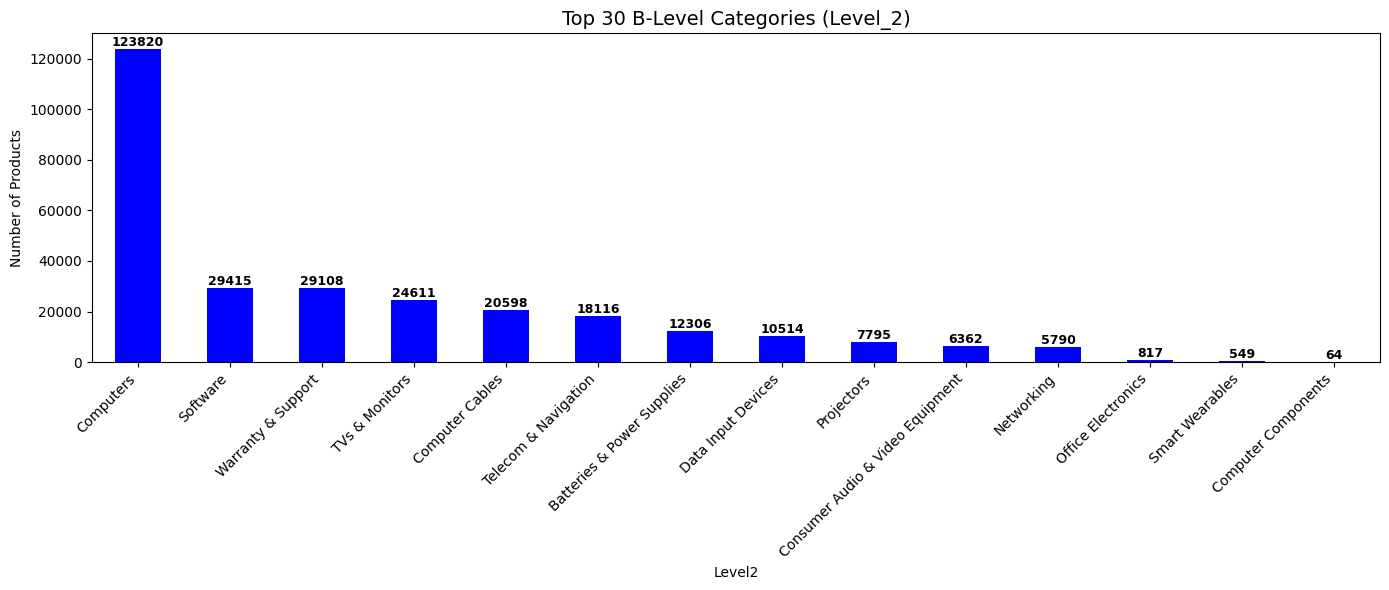

In [12]:
import matplotlib.pyplot as plt

# Count Level_2 categories
b_counts = df['Level2'].value_counts()

# Plot Top 20
plt.figure(figsize=(14, 6))
ax = b_counts.head(30).plot(kind='bar', color='blue')

# Add labels on top of bars
for i, count in enumerate(b_counts.head(30).values):
    ax.text(i, count + 5, str(count), ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.title("Top 30 B-Level Categories (Level_2)", fontsize=14)
plt.ylabel("Number of Products")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

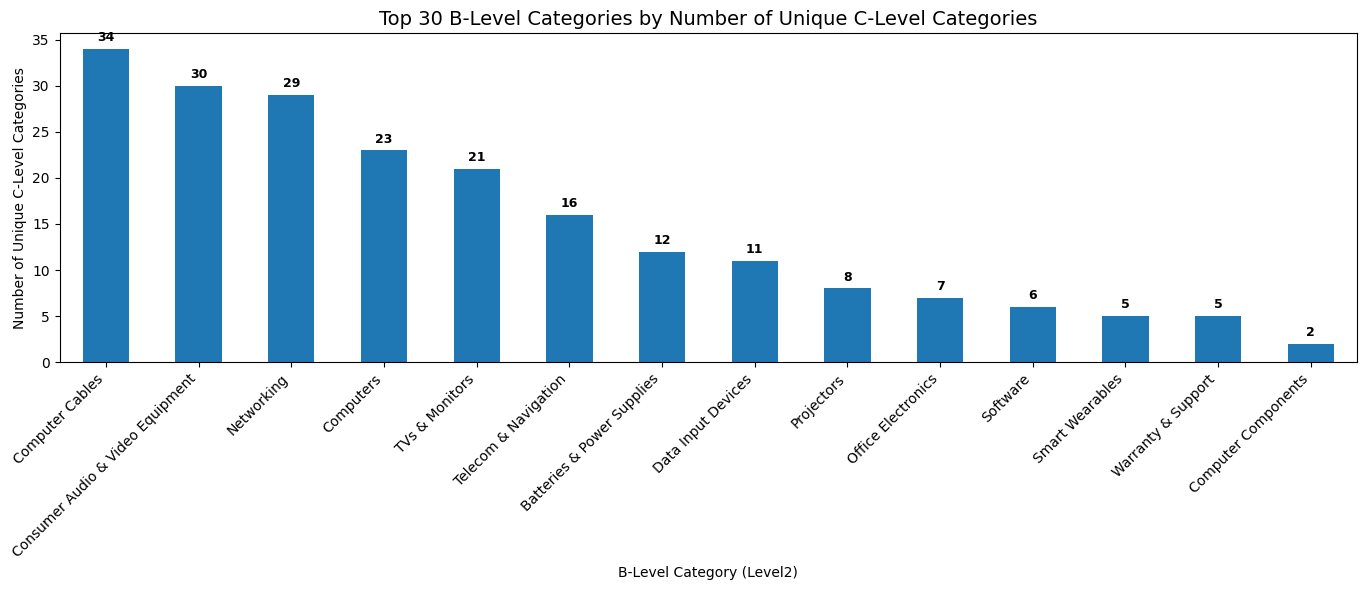

In [13]:
import matplotlib.pyplot as plt

# Count unique C-level categories per B-level
b_c_unique = (
    df.groupby("Level2")["Level3"]
    .nunique()
    .sort_values(ascending=False)
)

# Plot Top 30 B-levels by number of unique C-levels
plt.figure(figsize=(14, 6))
ax = b_c_unique.head(30).plot(kind='bar')

# Add labels on top of bars
for i, count in enumerate(b_c_unique.head(30).values):
    ax.text(i, count + 0.5, str(count), ha='center', va='bottom',
            fontsize=9, fontweight='bold')

plt.title("Top 30 B-Level Categories by Number of Unique C-Level Categories", fontsize=14)
plt.ylabel("Number of Unique C-Level Categories")
plt.xlabel("B-Level Category (Level2)")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


In [14]:
# sample_df[sample_df["ProductName"] == "EMS1000T"][["ProductName", "metadata_clean", "final_text"]]

In [15]:
# Sentence Embeddings

model = SentenceTransformer(EMBED_MODEL)

embeddings = model.encode(
    sample_df["metadata_clean"].tolist(),
    batch_size = 128,
    show_progress_bar=True,
    normalize_embeddings=True
)

print("Embedding shape:", embeddings.shape)

Batches:   0%|          | 0/343 [00:00<?, ?it/s]

Embedding shape: (43803, 384)


In [16]:
umap_model = UMAP(
    n_neighbors=50,
    min_dist=0.0,
    n_components=50,
    # n_components=10,
    metric="cosine",
    random_state=RANDOM_STATE
)

reduced = umap_model.fit_transform(embeddings)
print("Reduced shape:", reduced.shape)

/opt/anaconda3/envs/taxonomy_env/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Reduced shape: (43803, 50)


In [17]:
optics = OPTICS(
    min_samples=40,
    metric="euclidean",
    cluster_method="xi",
    xi=0.03, 
    min_cluster_size = 100
)

sample_df["C_id_optics"] = optics.fit_predict(reduced)

print("Clusters formed:", sample_df["C_id_optics"].nunique())
print(sample_df["C_id_optics"].value_counts().head(10))

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


Clusters formed: 169
C_id_optics
-1      19184
 32       376
 58       324
 1        285
 73       240
 165      239
 68       238
 107      235
 137      227
 39       217
Name: count, dtype: int64


In [18]:
# Evaluation (NO NOISE)
mask = sample_df["C_id_optics"] != -1

ari = adjusted_rand_score(
    sample_df.loc[mask, LABEL_COL],
    sample_df.loc[mask, "C_id_optics"]
)

nmi = normalized_mutual_info_score(
    sample_df.loc[mask, LABEL_COL],
    sample_df.loc[mask, "C_id_optics"]
)

print("ARI:", round(ari, 4))
print("NMI:", round(nmi, 4))

ARI: 0.5424
NMI: 0.8369


In [19]:
noise_ratio = (sample_df["C_id_optics"] == -1).mean()

print("Noise Ratio:", round(noise_ratio, 4))

Noise Ratio: 0.438


In [20]:

def cluster_purity(df, cluster_col, gold_col):
    stats = (
        df.groupby(cluster_col)[gold_col]
        .value_counts()
        .rename("count")
        .reset_index()
    )
    top = stats.groupby(cluster_col).first().reset_index()
    sizes = df[cluster_col].value_counts().rename("size").reset_index()
    merged = top.merge(sizes, on=cluster_col)
    merged["purity"] = merged["count"] / merged["size"]
    return merged.sort_values("purity", ascending=False)

purity_df = cluster_purity(sample_df, "C_id_optics", LABEL_COL)
purity_df.head(160)

,C_id_optics,Level3,count,size,purity
127,126,Dictaphones,116,116,1.000000
144,143,Household Batteries,158,158,1.000000
72,71,Remote Controls,126,126,1.000000
85,84,Mobile Phones,182,182,1.000000
98,97,Servers,107,107,1.000000
99,98,Projector Lamps,127,127,1.000000
102,101,Data Projectors,102,102,1.000000
110,109,Uninterruptible Power Supplies (UPSs),145,145,1.000000
111,110,Power Distribution Units (PDUs),155,155,1.000000
112,111,Power Distribution Units (PDUs),142,142,1.000000


In [21]:
sample_df[sample_df["C_id_optics"] == 147][["Brand", "ProductName", LABEL_COL]].head(1000)

,Brand,ProductName,Level3
1903,Acer,BATTERY CHARGER TM 610,Battery Chargers
9513,Acer,23.LBP0J.001,Flat Panel Spare Parts
9518,Acer,23.LK60J.001,Flat Panel Spare Parts
9634,Acer,55.D140J.008,Flat Panel Spare Parts
9648,Acer,55.D2301.014,Flat Panel Spare Parts
9698,Acer,55.C200J.001,Flat Panel Spare Parts
9701,Acer,23.LEX04.001,Flat Panel Spare Parts
9734,Acer,55.D2B0J.004,Flat Panel Spare Parts
9752,Acer,23.LQK0Q.001,Flat Panel Spare Parts
9770,Acer,55.D2301.025,Flat Panel Spare Parts


In [22]:
sample_df[sample_df["C_id_optics"] == 162][["Brand", "ProductName", "Level3"]].nunique()

Brand           17
ProductName    112
Level3           2
dtype: int64

In [23]:
example_cluster = sample_df["C_id_optics"].value_counts().index[4]

sample_df[sample_df["C_id_optics"] == example_cluster][["C_id_optics", "Brand", "ProductName", LABEL_COL]].head(100)

,C_id_optics,Brand,ProductName,Level3
4024,73,iiyama,E2410HDS-B1,Computer Monitors
4041,73,iiyama,B2283HS-B3,Computer Monitors
4066,73,iiyama,ProLite B1706S-B1,Computer Monitors
4134,73,EIZO,FDS1703,Computer Monitors
4171,73,iiyama,ProLite E2710HDS-1,Computer Monitors
4194,73,EIZO,EV2411WE-GY,Computer Monitors
4253,73,iiyama,E1906S-B,Computer Monitors
4276,73,Hannspree,HZ201DPB,Computer Monitors
4283,73,Hannspree,HP 194 DJB,Computer Monitors
4289,73,iiyama,B2280WSD-B1,Computer Monitors


In [24]:
example_cluster = sample_df["C_id_optics"].value_counts().index[14]

sample_df[sample_df["C_id_optics"] == example_cluster][["Brand", "ProductName", LABEL_COL]]

,Brand,ProductName,Level3
2202,Samsung,EB-K735EE,Battery Chargers
26666,Sandberg,Survivor Torch Powerbank 10400,Power Banks
26667,Sandberg,Survivor Powerbank 15600 Pro,Power Banks
26668,NGS,PowerPump 5000,Power Banks
26671,2-Power,UBP0109A,Power Banks
26673,Urban Factory,Power Bank Cosmic 20000mAh,Power Banks
26675,Tacens,APWB1,Power Banks
26678,Verbatim,49570,Power Banks
26681,Conceptronic,USB Multi Tip Power Pack 1500mAh,Power Banks
26682,Targus,iStore Mini,Power Banks


In [25]:
# Map each cluster to its dominant Level3
cluster_to_label = (
    sample_df
    .groupby("C_id_optics")[LABEL_COL]
    .agg(lambda x: x.value_counts().idxmax())
)

collapsed_preds = sample_df["C_id_optics"].map(cluster_to_label)

adjusted_rand_score(sample_df[LABEL_COL], collapsed_preds)


0.029862536941548494

In [26]:
def cluster_quality(df, cluster_col, gold_col):
    stats = (
        df.groupby(cluster_col)[gold_col]
        .value_counts()
        .rename("count")
        .reset_index()
    )

    sizes = df[cluster_col].value_counts().rename("size").reset_index()
    merged = stats.merge(sizes, on=cluster_col)

    # purity
    top = (
        merged.sort_values("count", ascending=False)
        .groupby(cluster_col)
        .first()
        .reset_index()
    )
    top["purity"] = top["count"] / top["size"]
    top["impurity"] = 1 - top["purity"]

    # entropy
    entropy = (
        merged.assign(p=lambda x: x["count"] / x["size"])
        .groupby(cluster_col)
        .apply(lambda g: -np.sum(g["p"] * np.log(g["p"])))
        .reset_index(name="entropy")
    )

    return top.merge(entropy, on=cluster_col).sort_values("impurity", ascending=False)


In [27]:
quality_df = cluster_quality(sample_df, "C_id_optics", LABEL_COL)

# Worst clusters by impurity
quality_df.head(1000)

/var/folders/b_/cv34fjz13m34nzs9_x_gpp600000gn/T/ipykernel_55704/315832772.py:26: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: -np.sum(g["p"] * np.log(g["p"])))


,C_id_optics,Level3,count,size,purity,impurity,entropy
0,-1,Portable Speakers,478,19184,0.024917,0.975083,4.591358
59,58,Flat Panel Desk Mounts,40,324,0.123457,0.876543,3.097228
31,30,HDMI Cables,20,102,0.196078,0.803922,2.582841
21,20,Power Cables,29,140,0.207143,0.792857,2.409115
136,135,Warranty & Support Extensions,21,101,0.207921,0.792079,2.412219
56,55,PCs/Workstations,32,132,0.242424,0.757576,2.153335
95,94,TVs,35,119,0.294118,0.705882,2.327730
61,60,Projection Lenses,30,102,0.294118,0.705882,2.253298
97,96,PCs/Workstations,37,119,0.310924,0.689076,1.507746
19,18,Internal Power Cables,55,167,0.329341,0.670659,1.726345


In [28]:
quality_df_valid = quality_df[quality_df["C_id_optics"] != -1]


In [29]:
overall_purity = (
    (quality_df_valid["purity"] * quality_df_valid["size"]).sum()
    / quality_df_valid["size"].sum()
)

overall_impurity = 1 - overall_purity

print("Overall weighted purity:", round(overall_purity, 4))
print("Overall weighted impurity:", round(overall_impurity, 4))

Overall weighted purity: 0.8092
Overall weighted impurity: 0.1908


In [30]:
example_cluster = sample_df["C_id_optics"].value_counts().index[49]

sample_df[sample_df["C_id_optics"] == example_cluster][["Brand", "ProductName", LABEL_COL]].head(1000)

,Brand,ProductName,Level3
9507,Acer,55.LHW0Q.009,Flat Panel Spare Parts
9510,Acer,55.LEY04.001,Flat Panel Spare Parts
9514,Acer,55.H0704.006,Flat Panel Spare Parts
9516,Acer,55.LL40J.001,Flat Panel Spare Parts
9522,Acer,55.LXKM2.005,Flat Panel Spare Parts
9528,Acer,55.LGL01.016,Flat Panel Spare Parts
9530,Acer,55.T0AM2.008,Flat Panel Spare Parts
9532,Acer,55.T1JM2.003,Flat Panel Spare Parts
9534,Acer,55.T4HM3.001,Flat Panel Spare Parts
9539,Acer,55.T0NM2.004,Flat Panel Spare Parts


In [31]:
sample_df[sample_df["C_id_optics"] == 49][["Brand", "ProductName", LABEL_COL]].head(1000)

,Brand,ProductName,Level3
1966,Lenovo,L13,Battery Chargers
2079,Lenovo,L15,Battery Chargers
2281,Lenovo,L14,Battery Chargers
6218,Lenovo,0A61769,Display Privacy Filters
6458,Lenovo,0C33167,Display Privacy Filters
6485,Lenovo,0B33486,Display Privacy Filters
6510,Lenovo,0B33487,Display Privacy Filters
11055,Lenovo,4XH0L55005,Handheld Device Accessories
11056,Lenovo,L8 Tip for RIM Blackberry and Selected Motorola Phones,Handheld Device Accessories
11106,Lenovo,41R4313,Handheld Device Accessories


In [32]:
sample_df[sample_df["C_id_optics"] == 49][["Brand", "ProductName", LABEL_COL]].nunique()

Brand            4
ProductName    177
Level3          12
dtype: int64

In [33]:
sample_df[sample_df["C_id_optics"] == 108][["Brand", "ProductName", LABEL_COL]].nunique()

Brand            2
ProductName    155
Level3           8
dtype: int64

In [34]:
sample_df[sample_df["C_id_optics"] == 108][["Brand", "ProductName", LABEL_COL]].head(1000)

,Brand,ProductName,Level3
9380,APC,CDU Flexible Fluid Piping Clamp/Hanger (qty of 50),Flat Panel Mount Accessories
9476,APC,CDU Flexible Fluid Piping Couplings (4 per pack),Flat Panel Mount Accessories
14465,APC,KVM to Rack PDU Power Mgmt,KVM Cables
14889,APC,2x1x16 Digital KVM,KVM Switches
21714,APC,UTSHW,Network Switch Components
27496,APC,International power adapter,Power Cables
27667,APC,PRM24,Power Distribution Units (PDUs)
27669,APC,PDM3563IEC-200,Power Distribution Units (PDUs)
27675,APC,"Rack PDU, Switched, Zero U, 11kW, 230V, (21) C13, (3) C19",Power Distribution Units (PDUs)
27678,APC,"MasterSwitch, 1U, 12A, 208&230V, (8)C13",Power Distribution Units (PDUs)


In [35]:
sample_df[sample_df["ProductName"] == "CUSTOM-SIGNAGEPLAYER"][["metadata_clean", "final_text"]]

,metadata_clean,final_text
24373,advantech custom-signageplayer,pc workstation barebones advantech custom signageplayer


In [36]:
df_valid = sample_df[sample_df["C_id_optics"] != -1].copy()

print("Products used for taxonomy:", len(df_valid))
print("C-level clusters:", df_valid["C_id_optics"].nunique())

Products used for taxonomy: 24619
C-level clusters: 168


In [37]:
# ════════════════════════════════════════════════════════════
# CELL 2 — Make sure df_valid was built correctly
# If you are unsure, rebuild it cleanly right here
# ════════════════════════════════════════════════════════════

# This is the single correct definition of df_valid
# Run this before ANY naming or evaluation step

df_valid = sample_df[sample_df["C_id_optics"] != -1].copy()
df_noise = sample_df[sample_df["C_id_optics"] == -1].copy()

print(f"df_valid : {len(df_valid):,} products  across {df_valid['C_id_optics'].nunique()} C clusters")
print(f"df_noise : {len(df_noise):,} products  (excluded from all naming and evaluation)")

# Sanity check — no cluster ID -1 in df_valid
assert (df_valid["C_id_optics"] == -1).sum() == 0
print("\n✅ Clean split confirmed")

df_valid : 24,619 products  across 168 C clusters
df_noise : 19,184 products  (excluded from all naming and evaluation)

✅ Clean split confirmed


In [38]:
def sample_texts_per_cluster(
    df,
    cluster_col,
    text_col,
    n_samples=30,
    seed=42
):
    sampled = {}
    for cid, g in df.groupby(cluster_col):
        n = min(len(g), n_samples)
        sampled[cid] = g.sample(n=n, random_state=seed)[text_col].tolist()
    return sampled

c_cluster_texts = sample_texts_per_cluster(
    df_valid,
    cluster_col="C_id_optics",
    text_col="metadata_clean",
    n_samples=30
)

len(c_cluster_texts)

168

In [39]:
def make_evidence(subdf, max_items=40, max_len=180):
    texts = (
        subdf["metadata_text"]
        .dropna()
        .sample(min(len(subdf), max_items), random_state=42)
        .tolist()
    )
    return "\n".join(t[:max_len] for t in texts)

In [40]:
# pip install llama-stack

In [41]:
import bitsandbytes
print(bitsandbytes.__version__)  # should be >= 0.39.0

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


0.49.2


In [42]:
# # ============================================================
# # CELL — Ollama setup + C-level naming (single clean cell)
# # ============================================================
# import os
# import re
# import ollama

# os.environ["TOKENIZERS_PARALLELISM"] = "false"

# # ── Verify Ollama ─────────────────────────────────────────
# try:
#     models_response = ollama.list()
#     pulled = [m.model for m in models_response.models]
#     assert any("llama3.1" in m for m in pulled), "llama3.1:8b not pulled"
#     print(f"✅ Ollama running. Models: {pulled}")
# except Exception as e:
#     print(f"❌ Ollama error: {e}")


# # ── Cleaner ───────────────────────────────────────────────
# def clean_cluster_name(raw: str) -> str:
#     name = raw.strip()
#     name = re.sub(r"\*+", "", name)
#     name = name.split("\n")[0].strip()
#     name = re.sub(
#         r"^(here\s+(is|are)\s+(a\s+)?(the\s+)?(few\s+)?(possible\s+)?"
#         r"(broad\s+)?(parent\s+)?(category\s+)?(name[s]?\s*)?[:：]?\s*)",
#         "", name, flags=re.IGNORECASE
#     ).strip()
#     name = re.sub(
#         r"^(category\s*(name\s*)?[:：]|the best category( name)? is\s*[:：]?|answer\s*[:：])",
#         "", name, flags=re.IGNORECASE
#     ).strip()
#     name = re.sub(r"[^a-zA-Z& /]", " ", name)
#     name = re.sub(r"\s+", " ", name).strip().lower()
#     name = re.sub(r"\s*(and more|etc|and so on)$", "", name).strip()
#     return name


# # ── Validator ─────────────────────────────────────────────
# def is_valid_category_name(name: str) -> bool:
#     if not name or len(name) < 3:
#         return False
#     name = name.strip().lower()
#     if len(name.split()) > 6:
#         return False
#     if re.search(r"\d", name):
#         return False
#     forbidden = [
#         "asus", "lenovo", "hp", "dell", "intel", "nvidia", "amd",
#         "apple", "samsung", "microsoft", "cisco", "logitech",
#         "here is", "here are", "possible", "broad parent",
#         "category name", "few possible", "best category"
#     ]
#     if any(b in name for b in forbidden):
#         return False
#     if not re.fullmatch(r"[a-z&/ ]+", name):
#         return False
#     return True


# # ── C-level LLM call — few-shot format ───────────────────
# def run_llm(user_block: str, max_new_tokens: int = 10) -> str:
#     """
#     Few-shot conversation format.
#     The assistant example turn shows the exact output format expected.
#     max_new_tokens=10 physically prevents preamble sentences.
#     stop tokens cut generation at the first sentence boundary.
#     """
#     response = ollama.chat(
#         model="llama3.1:8b",
#         messages=[
#             # ── Few-shot example ──────────────────────────
#             {
#                 "role": "user",
#                 "content": (
#                     "Sub-categories: wireless routers, ethernet switches, "
#                     "network cables, wifi access points\n"
#                     "Category name (2-5 words, plural noun):"
#                 )
#             },
#             {
#                 "role": "assistant",
#                 "content": "networking equipment"
#             },
#             # ── Real prompt ───────────────────────────────
#             {
#                 "role": "user",
#                 "content": (
#                     f"{user_block}\n"
#                     "Category name (2-5 words, plural noun):"
#                 )
#             }
#         ],
#         options={
#             "num_predict": 10,
#             "temperature": 0,
#             "num_ctx": 2048,
#             "stop": ["\n", ".", "1.", "Here", "I ", "The ", "Based"],
#         }
#     )
#     raw = response.message.content.strip()
#     return raw.split("\n")[0].strip()


# # ── User block builder ────────────────────────────────────
# def build_cluster_user_block(texts, max_texts=30, max_len=200):
#     """
#     Compact: pass C_names as sub-category hints + sample texts.
#     Limits text length to avoid overwhelming the context window.
#     """
#     bullets = "\n".join(f"- {t[:max_len]}" for t in texts[:max_texts])
#     return (
#         "Sub-categories in this group:\n"
#         f"{bullets}"
#     )


# # ── Generator with logging ────────────────────────────────
# def generate_c_name_for_cluster(cluster_id, df, max_retries=3):
#     texts = (
#         df[df["C_id_optics"] == cluster_id]["metadata_clean"]
#         .dropna()
#         .head(30)
#         .tolist()
#     )

#     if not texts:
#         print(f"    ⚠️  C_id {cluster_id}: no texts — fallback")
#         return "miscellaneous products"

#     user_block = build_cluster_user_block(texts)

#     for attempt in range(max_retries):
#         raw   = run_llm(user_block)
#         name  = clean_cluster_name(raw)
#         valid = is_valid_category_name(name)
#         print(f"    C_id {cluster_id} attempt {attempt+1}: "
#               f"raw={repr(raw)}  cleaned={repr(name)}  valid={valid}")
#         if valid:
#             return name

#     # Last resort — use whatever the LLM last produced
#     # as long as it doesn't look like a preamble sentence
#     last = clean_cluster_name(run_llm(user_block))
#     if (last and len(last) > 2
#             and "here" not in last
#             and "possible" not in last
#             and "best category" not in last):
#         print(f"    ⚠️  C_id {cluster_id}: using last output: {repr(last)}")
#         return last

#     print(f"    ⚠️  C_id {cluster_id}: all retries failed — miscellaneous")
#     return "miscellaneous products"


# # ── Test ─────────────────────────────────────────────────
# test_texts = [
#     "wireless router dual band home network",
#     "mesh wifi system whole home coverage",
#     "network range extender plug in wall",
# ]
# result = run_llm(build_cluster_user_block(test_texts))
# print(f"✅ Test output: {repr(result)}")
# print(f"   Cleaned    : {repr(clean_cluster_name(result))}")
# print(f"   Valid      : {is_valid_category_name(clean_cluster_name(result))}")

In [46]:
# ════════════════════════════════════════════════════════════
# C-LEVEL NAMING — complete single cell
# ════════════════════════════════════════════════════════════
import os, re, ollama
from tqdm import tqdm

os.environ["TOKENIZERS_PARALLELISM"] = "false"

# ── Cleaner ───────────────────────────────────────────────
def clean_cluster_name(raw: str) -> str:
    name = raw.strip()
    name = re.sub(r"\*+", "", name)
    name = name.split("\n")[0].strip()
    name = re.sub(
        r"^(here\s+(is|are)\s+(a\s+)?(the\s+)?(few\s+)?(possible\s+)?"
        r"(broad\s+)?(parent\s+)?(category\s+)?(name[s]?\s*)?[:：]?\s*)",
        "", name, flags=re.IGNORECASE
    ).strip()
    name = re.sub(
        r"^(category\s*(name\s*)?[:：]|the best category( name)? is\s*[:：]?|answer\s*[:：])",
        "", name, flags=re.IGNORECASE
    ).strip()
    name = re.sub(r"[^a-zA-Z& /]", " ", name)
    name = re.sub(r"\s+", " ", name).strip().lower()
    name = re.sub(r"\s*(and more|etc|and so on)$", "", name).strip()
    return name


# ── Validator ─────────────────────────────────────────────
def is_valid_category_name(name: str) -> bool:
    if not name or len(name) < 3:
        return False
    name = name.strip().lower()
    if len(name.split()) > 6:
        return False
    if re.search(r"\d", name):
        return False
    forbidden = [
        "asus", "lenovo", "hp", "dell", "intel", "nvidia", "amd",
        "apple", "samsung", "microsoft", "cisco", "logitech",
        "here is", "here are", "possible", "broad parent",
        "category name", "few possible", "best category",
        "product description", "same category"
    ]
    if any(b in name for b in forbidden):
        return False
    if not re.fullmatch(r"[a-z&/ ]+", name):
        return False
    return True


# ── LLM call — few-shot format ────────────────────────────
def run_llm(user_block: str, max_new_tokens: int = 10) -> str:
    response = ollama.chat(
        model="llama3.1:8b",
        messages=[
            {
                "role": "user",
                "content": (
                    "Sub-categories: wireless routers, ethernet switches, "
                    "network cables, wifi access points\n"
                    "Category name (2-5 words, plural noun):"
                )
            },
            {
                "role": "assistant",
                "content": "networking equipment"
            },
            {
                "role": "user",
                "content": (
                    f"{user_block}\n"
                    "Category name (2-5 words, plural noun):"
                )
            }
        ],
        options={
            "num_predict": 10,
            "temperature": 0,
            "num_ctx": 2048,
            "stop": ["\n", ".", "1.", "Here", "I ", "The ", "Based"],
        }
    )
    raw = response.message.content.strip()
    return raw.split("\n")[0].strip()


# ── User block builder ────────────────────────────────────
def build_cluster_user_block(texts, max_texts=30, max_len=200):
    bullets = "\n".join(f"- {t[:max_len]}" for t in texts[:max_texts])
    return f"Sub-categories in this group:\n{bullets}"


# ── Generator ─────────────────────────────────────────────
def generate_c_name_for_cluster(cluster_id, df, max_retries=3):
    texts = (
        df[df["C_id_optics"] == cluster_id]["metadata_clean"]
        .dropna()
        .head(30)
        .tolist()
    )

    if not texts:
        print(f"    ⚠️  C_id {cluster_id}: no texts")
        return "miscellaneous products"

    user_block = build_cluster_user_block(texts)

    for attempt in range(max_retries):
        raw   = run_llm(user_block)
        name  = clean_cluster_name(raw)
        valid = is_valid_category_name(name)
        print(f"    C_id {cluster_id} attempt {attempt+1}: "
              f"raw={repr(raw)}  cleaned={repr(name)}  valid={valid}")
        if valid:
            return name

    # Last resort — use LLM output if it looks clean
    last = clean_cluster_name(run_llm(user_block))
    if (last and len(last) > 2
            and "here"     not in last
            and "possible" not in last
            and "best"     not in last
            and "category" not in last):
        print(f"    ⚠️  C_id {cluster_id}: using last: {repr(last)}")
        return last

    print(f"    ⚠️  C_id {cluster_id}: all retries failed — miscellaneous")
    return "miscellaneous products"


# ════════════════════════════════════════════════════════════
# SANITY TEST — must pass before running full loop
# ════════════════════════════════════════════════════════════

test_texts = [
    "wireless router dual band home network",
    "mesh wifi system whole home coverage",
    "network range extender plug in wall",
]
_result  = run_llm(build_cluster_user_block(test_texts))
_cleaned = clean_cluster_name(_result)
_valid   = is_valid_category_name(_cleaned)

print(f"Test raw     : {repr(_result)}")
print(f"Test cleaned : {repr(_cleaned)}")
print(f"Test valid   : {_valid}")
assert _valid, "❌ Test failed — fix run_llm before proceeding"
print("✅ Test passed\n")


# ════════════════════════════════════════════════════════════
# RUN C-LEVEL NAMING
# ════════════════════════════════════════════════════════════

valid_cluster_ids = sorted(
    df_valid[df_valid["C_id_optics"] != -1]["C_id_optics"].unique()
)
print(f"Naming {len(valid_cluster_ids)} C clusters...\n")

c_id_to_name = {}

for cid in tqdm(valid_cluster_ids, desc="Naming C clusters"):
    c_id_to_name[cid] = generate_c_name_for_cluster(cid, df_valid)

# ── Assign back to df_valid ───────────────────────────────
df_valid["C_name"] = df_valid["C_id_optics"].map(c_id_to_name)

# ── Summary ───────────────────────────────────────────────
misc_count  = sum(1 for v in c_id_to_name.values() if v == "miscellaneous products")
named_count = len(c_id_to_name) - misc_count

print(f"\n{'='*50}")
print(f"C-LEVEL NAMING COMPLETE")
print(f"{'='*50}")
print(f"  Total C clusters : {len(c_id_to_name)}")
print(f"  Properly named   : {named_count}")
print(f"  Miscellaneous    : {misc_count}")
print(f"  Null in df_valid : {df_valid['C_name'].isna().sum()}")
print(f"\nSample c_id_to_name (first 10):")
for k, v in list(c_id_to_name.items())[:10]:
    print(f"  C_id {k:>4} → {v}")

Test raw     : 'Wireless Routers'
Test cleaned : 'wireless routers'
Test valid   : True
✅ Test passed

Naming 168 C clusters...



Naming C clusters:   1%|          | 1/168 [00:14<40:37, 14.60s/it]

    C_id 0 attempt 1: raw='HDM'  cleaned='hdm'  valid=True


Naming C clusters:   1%|          | 2/168 [00:28<38:57, 14.08s/it]

    C_id 1 attempt 1: raw='Video adapters and converters'  cleaned='video adapters and converters'  valid=True


...

Naming C clusters:  99%|█████████▉| 167/168 [39:05<00:15, 15.14s/it]

    C_id 166 attempt 1: raw='Antivirus and Security Software'  cleaned='antivirus and security software'  valid=True


Naming C clusters: 100%|██████████| 168/168 [39:21<00:00, 14.06s/it]

    C_id 167 attempt 1: raw='fax machines'  cleaned='fax machines'  valid=True

C-LEVEL NAMING COMPLETE
  Total C clusters : 168
  Properly named   : 165
  Miscellaneous    : 3


  Null in df_valid : 0

Sample c_id_to_name (first 10):
  C_id    0 → hdm
  C_id    1 → video adapters and converters
  C_id    2 → kvm switches
  C_id    3 → kvm switches
  C_id    4 → kvm cables
  C_id    5 → miscellaneous products
  C_id    6 → video adapters
  C_id    7 → video cables
  C_id    8 → vga cables
  C_id    9 → hdm


In [61]:
# ─────────────────────────────────────────────────────────────────────
# CELL 1 — Split valid / noise
# ─────────────────────────────────────────────────────────────────────
df_valid = sample_df[sample_df["C_id_optics"] != -1].copy()
df_noise = sample_df[sample_df["C_id_optics"] == -1].copy()

print(f"df_valid : {len(df_valid):,} products across {df_valid['C_id_optics'].nunique()} C clusters")
print(f"df_noise : {len(df_noise):,} products (excluded from naming)")
assert (df_valid["C_id_optics"] == -1).sum() == 0
print("\n✅ Clean split confirmed")

df_valid : 24,619 products across 168 C clusters
df_noise : 19,184 products (excluded from naming)

✅ Clean split confirmed


In [62]:
# ─────────────────────────────────────────────────────────────────────
# CELL 2 — Sample texts per cluster (input for LLM)
# ─────────────────────────────────────────────────────────────────────
def sample_texts_per_cluster(df, cluster_col, text_col, n_samples=30, seed=42):
    sampled = {}
    for cid, g in df.groupby(cluster_col):
        n = min(len(g), n_samples)
        sampled[cid] = g.sample(n=n, random_state=seed)[text_col].tolist()
    return sampled

c_cluster_texts = sample_texts_per_cluster(
    df_valid,
    cluster_col="C_id_optics",
    text_col="metadata_clean",   # ← always use the cleaned column
    n_samples=30
)
print(f"Clusters ready for naming: {len(c_cluster_texts)}")

Clusters ready for naming: 168


In [45]:
# ─────────────────────────────────────────────────────────────────────
# CELL 3 — Ollama setup + all naming helpers (ONE definition each)
# ─────────────────────────────────────────────────────────────────────
import os
import re
import ollama
from tqdm import tqdm

os.environ["TOKENIZERS_PARALLELISM"] = "false"

# ── 3a. Verify Ollama ─────────────────────────────────────────────
models_response = ollama.list()
pulled = [m.model for m in models_response.models]
assert any("llama3.1" in m for m in pulled), "llama3.1:8b not found — run: ollama pull llama3.1:8b"
print(f"✅ Ollama running. Models: {pulled}")


# ── 3b. LLM call (few-shot, tightly constrained) ─────────────────
def run_llm(user_block: str) -> str:
    response = ollama.chat(
        model="llama3.1:8b",
        messages=[
            # Few-shot example — teaches the exact output format
            {
                "role": "user",
                "content": (
                    "Sub-categories: wireless routers, ethernet switches, "
                    "network cables, wifi access points\n"
                    "Category name (2-5 words, plural noun):"
                )
            },
            {"role": "assistant", "content": "networking equipment"},
            # Real prompt
            {
                "role": "user",
                "content": f"{user_block}\nCategory name (2-5 words, plural noun):"
            }
        ],
        options={
            "num_predict": 10,          # hard cap — prevents rambling
            "temperature": 0,
            "num_ctx": 2048,
            "stop": ["\n", ".", "1.", "Here", "I ", "The ", "Based"],
        }
    )
    return response.message.content.strip().split("\n")[0].strip()


# ── 3c. Build the user prompt block ──────────────────────────────
def build_cluster_user_block(texts, max_texts=30, max_len=200):
    """Feed sampled metadata_clean texts as bullet points."""
    bullets = "\n".join(f"- {t[:max_len]}" for t in texts[:max_texts])
    return f"Sub-categories in this group:\n{bullets}"


# ── 3d. Clean raw LLM output ─────────────────────────────────────
def clean_cluster_name(raw: str) -> str:
    name = raw.strip()
    name = re.sub(r"\*+", "", name)
    name = name.split("\n")[0].strip()
    # Strip common LLM preambles
    name = re.sub(
        r"^(here\s+(is|are)\s+(a\s+)?(the\s+)?(few\s+)?(possible\s+)?"
        r"(broad\s+)?(parent\s+)?(category\s+)?(name[s]?\s*)?[:：]?\s*)",
        "", name, flags=re.IGNORECASE
    ).strip()
    name = re.sub(
        r"^(category\s*(name\s*)?[:：]|the best category( name)? is\s*[:：]?|answer\s*[:：])",
        "", name, flags=re.IGNORECASE
    ).strip()
    # Keep only letters, &, /
    name = re.sub(r"[^a-zA-Z& /]", " ", name)
    name = re.sub(r"\s+", " ", name).strip().lower()
    name = re.sub(r"\s*(and more|etc|and so on)$", "", name).strip()
    return name


# ── 3e. Validate the cleaned name ────────────────────────────────
BRAND_BLOCKLIST = [
    "asus", "lenovo", "hp", "dell", "intel", "nvidia", "amd",
    "apple", "samsung", "microsoft", "cisco", "logitech",
]
PHRASE_BLOCKLIST = [
    "here is", "here are", "possible", "broad parent",
    "category name", "few possible", "best category",
]

def is_valid_category_name(name: str) -> bool:
    if not name or len(name) < 3:
        return False
    name = name.strip().lower()
    if len(name.split()) > 6:        # max 6 words for C-level
        return False
    if re.search(r"\d", name):       # no numbers
        return False
    if any(b in name for b in BRAND_BLOCKLIST):
        return False
    if any(p in name for p in PHRASE_BLOCKLIST):
        return False
    if not re.fullmatch(r"[a-z& /]+", name):   # only letters, &, /
        return False
    return True


# ── 3f. Name one cluster with retries ────────────────────────────
def generate_c_name_for_cluster(cluster_id, df, max_retries=3):
    texts = (
        df[df["C_id_optics"] == cluster_id]["metadata_clean"]
        .dropna()
        .head(30)
        .tolist()
    )
    if not texts:
        print(f"  ⚠️  C_id {cluster_id}: no texts — fallback")
        return "miscellaneous products"

    user_block = build_cluster_user_block(texts)

    last_valid = None
    for attempt in range(max_retries):
        raw   = run_llm(user_block)
        name  = clean_cluster_name(raw)
        valid = is_valid_category_name(name)
        print(f"  C_id {cluster_id} attempt {attempt+1}: "
              f"raw={repr(raw)}  cleaned={repr(name)}  valid={valid}")
        if valid:
            return name
        if name and len(name) > 2:
            last_valid = name   # save best effort even if not perfect

    # Use last non-empty output rather than hard-coding "miscellaneous"
    if last_valid and "here" not in last_valid and "possible" not in last_valid:
        print(f"  ⚠️  C_id {cluster_id}: using best-effort: {repr(last_valid)}")
        return last_valid

    print(f"  ⚠️  C_id {cluster_id}: all retries failed — miscellaneous")
    return "miscellaneous products"


# ── Quick smoke test ──────────────────────────────────────────────
_test_texts = [
    "wireless router dual band home network",
    "mesh wifi system whole home coverage",
    "network range extender plug in wall",
]
_result = run_llm(build_cluster_user_block(_test_texts))
print(f"✅ Test output: {repr(clean_cluster_name(_result))}")

✅ Ollama running. Models: ['llama3.1:8b']
✅ Test output: 'wireless routers'


In [64]:
# ─────────────────────────────────────────────────────────────────────
# CELL 4 — Run naming for all clusters
# ─────────────────────────────────────────────────────────────────────
c_id_to_name = {}

for cid in tqdm(sorted(df_valid["C_id_optics"].unique())):
    c_id_to_name[cid] = generate_c_name_for_cluster(cid, df_valid)

print(f"\nNaming complete. {len(c_id_to_name)} clusters named.")

  1%|          | 1/168 [00:13<36:33, 13.14s/it]

  C_id 0 attempt 1: raw='HDM'  cleaned='hdm'  valid=True


  1%|          | 2/168 [00:24<33:07, 11.97s/it]

  C_id 1 attempt 1: raw='Video adapters and converters'  cleaned='video adapters and converters'  valid=True


  2%|▏         | 3/168 [00:35<31:31, 11.46s/it]

...

  C_id 165 attempt 1: raw='antivirus software licenses'  cleaned='antivirus software licenses'  valid=True


 99%|█████████▉| 167/168 [38:52<00:14, 14.59s/it]

  C_id 166 attempt 1: raw='Antivirus and Security Software'  cleaned='antivirus and security software'  valid=True


100%|██████████| 168/168 [39:06<00:00, 13.97s/it]

  C_id 167 attempt 1: raw='fax machines'  cleaned='fax machines'  valid=True

Naming complete. 168 clusters named.


In [65]:
# ─────────────────────────────────────────────────────────────────────
# CELL 5 — Attach C_name to df_valid and inspect
# ─────────────────────────────────────────────────────────────────────
df_valid["C_name"] = df_valid["C_id_optics"].map(c_id_to_name)

# How many unique C_names were generated?
print(df_valid["C_name"].nunique(), "unique C-level names")

# Any duplicates? (multiple C_id_optics -> same C_name is expected but worth seeing)
print(df_valid.groupby("C_name")["C_id_optics"].nunique().sort_values(ascending=False).head(20))

# How many fell back to "miscellaneous products"?
print("\nMiscellaneous fallbacks:", (df_valid["C_name"] == "miscellaneous products").sum())

129 unique C-level names
C_name
network cables                  5
computer monitors               4
calculators                     3
miscellaneous products          3
home theater systems            3
all in one desktop computers    3
keyboards                       3
kvm switches                    2
computer systems                2
computers and workstations      2
power distribution units        2
server systems                  2
power supplies                  2
display privacy filters         2
televisions                     2
ethernet switches               2
fiber optic cables              2
projector lamps                 2
display screens or monitors     2
computer cables                 2
Name: C_id_optics, dtype: int64

Miscellaneous fallbacks: 479


In [54]:
df_valid["C_name"] = df_valid["C_id_optics"].map(c_id_to_name)

# df_valid[["C_id_optics", "C_name"]].drop_duplicates().head(20)

In [66]:
df_valid.groupby("C_name")["C_id_optics"].nunique().sort_values(ascending=False)


C_name
network cables                        5
computer monitors                     4
calculators                           3
miscellaneous products                3
home theater systems                  3
all in one desktop computers          3
keyboards                             3
kvm switches                          2
computer systems                      2
computers and workstations            2
power distribution units              2
server systems                        2
power supplies                        2
display privacy filters               2
televisions                           2
ethernet switches                     2
fiber optic cables                    2
projector lamps                       2
display screens or monitors           2
computer cables                       2
hdm                                   2
thin client devices                   2
wireless access points                2
batteries and power cells             2
portable cd players              

In [67]:
df_valid.columns

Index(['Brand', 'BrandPartCode', 'ProductName', 'Description.LongProductName',
       'Description.LongDesc', 'SummaryDescription.LongSummaryDescription',
       'pathlist_names', 'Level1', 'Level2', 'Level3', 'metadata_text',
       'metadata_clean', 'final_text', 'C_id_optics', 'C_name'],
      dtype='object')

In [68]:
df_valid.groupby("C_name").size().sort_values(ascending=False).head(150)

C_name
network cables                        741
computer monitors                     623
calculators                           496
miscellaneous products                479
uninterruptible power supplies ups    380
portable chargers                     376
keyboards                             370
home theater systems                  369
all in one desktop computers          365
hdm                                   360
power supplies                        331
batteries and power cells             330
accessories and peripherals           324
portable cd players                   322
wireless access points                315
antivirus and security software       311
fiber optic cables                    309
display screens or monitors           304
power distribution units              298
kvm switches                          298
video adapters and converters         285
projector lamps                       273
computer systems                      266
display privacy filters    

In [70]:
# ─────────────────────────────────────────────────────────────────────
# CELL 5 — Attach C_name to df_valid and inspect
# ─────────────────────────────────────────────────────────────────────
df_valid["C_name"] = df_valid["C_id_optics"].map(c_id_to_name)

# How many unique C_names were generated?
print(df_valid["C_name"].nunique(), "unique C-level names")

# Any duplicates? (multiple C_id_optics -> same C_name is expected but worth seeing)
print(df_valid.groupby("C_name")["C_id_optics"].nunique().sort_values(ascending=False).head(20))

# How many fell back to "miscellaneous products"?
print("\nMiscellaneous fallbacks:", (df_valid["C_name"] == "miscellaneous products").sum())


129 unique C-level names
C_name
network cables                  5
computer monitors               4
calculators                     3
miscellaneous products          3
home theater systems            3
all in one desktop computers    3
keyboards                       3
kvm switches                    2
computer systems                2
computers and workstations      2
power distribution units        2
server systems                  2
power supplies                  2
display privacy filters         2
televisions                     2
ethernet switches               2
fiber optic cables              2
projector lamps                 2
display screens or monitors     2
computer cables                 2
Name: C_id_optics, dtype: int64

Miscellaneous fallbacks: 479


In [71]:
df_vis = df_valid[df_valid["C_id_optics"] != -1].copy()

confusion = (
    df_vis
    .groupby(["C_name", LABEL_COL])
    .size()
    .reset_index(name="count")
)

In [72]:
confusion["pct_within_C_name"] = (
    confusion["count"] /
    confusion.groupby("C_name")["count"].transform("sum")
)

In [73]:
df_valid["C_name"].unique()

array(['hdm', 'network cables', 'wireless access points',
       'video adapters and converters', 'all in one desktop computers',
       'computers and workstations', 'all in one pcs', 'hp products',
       'computing devices', 'toshiba electronics devices', 'computers',
       'laptops and notebooks', 'antivirus software licenses',
       'antivirus and security software', 'antivirus software suites',
       'hardware support contracts', 'audio and video cables',
       'audio cables', 'accessories and peripherals',
       'fiber optic cables', 'battery chargers',
       'acer adapters and accessories', 'backup batteries',
       'batteries and power cells', 'accessories for tablets',
       'portable chargers', 'sony tv mounts',
       'batteries and power supplies', 'portable power banks',
       'power adapters', 'portable cd players', 'digital photo frames',
       'portable music players', 'video adapters', 'computer cables',
       'power cables', 'network connectors', 'patch pa

In [74]:
confusion_sorted = (
    confusion
    .sort_values(["C_name", "pct_within_C_name"], ascending=[True, False])
)

confusion_sorted.head(20)


,C_name,Level3,count,pct_within_C_name
10,accessories and peripherals,Flat Panel Desk Mounts,40,0.123457
16,accessories and peripherals,Handheld Device Accessories,35,0.108025
14,accessories and peripherals,Flat Panel Wall Mounts,26,0.080247
11,accessories and peripherals,Flat Panel Floor Stands,25,0.077160
8,accessories and peripherals,Flat Panel Accessories,24,0.074074
12,accessories and peripherals,Flat Panel Mount Accessories,23,0.070988
33,accessories and peripherals,Projector Accessories,20,0.061728
17,accessories and peripherals,Holders,16,0.049383
22,accessories and peripherals,MP3/MP4 Players,15,0.046296
13,accessories and peripherals,Flat Panel Spare Parts,11,0.033951


In [75]:
def print_cname_confusion(conf_df, top_k=5):
    for cname, g in conf_df.groupby("C_name"):
        print(f"\nC_name: {cname}")
        for _, row in g.head(top_k).iterrows():
            print(f"  └─ {row[LABEL_COL]} : {row['pct_within_C_name']:.2%}")

print_cname_confusion(confusion_sorted, top_k=5)


C_name: accessories and peripherals
  └─ Flat Panel Desk Mounts : 12.35%
  └─ Handheld Device Accessories : 10.80%
  └─ Flat Panel Wall Mounts : 8.02%
  └─ Flat Panel Floor Stands : 7.72%
  └─ Flat Panel Accessories : 7.41%

C_name: accessories for devices
  └─ Stylus Pens : 84.46%
  └─ Mobile Phone Spare Parts : 4.66%
  └─ Handheld Device Accessories : 3.63%
  └─ Screen Protectors : 3.11%
  └─ Flat Panel Accessories : 1.04%

C_name: accessories for tablets
  └─ Mobile Device Keyboards : 66.84%
  └─ Mobile Device Dock Stations : 19.47%
  └─ Handheld Device Accessories : 4.21%
  └─ Display Privacy Filters : 2.11%
  └─ Tablet Spare Parts : 2.11%

C_name: acer adapters and accessories
  └─ Projector Accessories : 66.12%
  └─ Flat Panel Spare Parts : 8.20%
  └─ Mobile Phone Spare Parts : 7.10%
  └─ Tablet Spare Parts : 7.10%
  └─ Stylus Pens : 6.01%

C_name: acer mainboards
  └─ Flat Panel Spare Parts : 96.88%
  └─ Stylus Pens : 1.88%
  └─ Tablet Spare Parts : 1.25%

C_name: all in one de

In [76]:
confusion["total_in_C"] = (
    confusion.groupby("C_name")["count"].transform("sum")
)


In [77]:
def print_cname_confusion(conf_df, top_k=5):
    for cname, g in conf_df.groupby("C_name"):
        total = confusion["total_in_C"].iloc[0]
        print(f"\nC_name: {cname} (n = {total})")
        for _, row in g.head(top_k).iterrows():
            print(
                f"  └─ {row[LABEL_COL]} : "
                f"{row['pct_within_C_name']:.2%} (n = {row['count']})"
            )
print_cname_confusion(confusion_sorted, top_k=5)


C_name: accessories and peripherals (n = 324)
  └─ Flat Panel Desk Mounts : 12.35% (n = 40)
  └─ Handheld Device Accessories : 10.80% (n = 35)
  └─ Flat Panel Wall Mounts : 8.02% (n = 26)
  └─ Flat Panel Floor Stands : 7.72% (n = 25)
  └─ Flat Panel Accessories : 7.41% (n = 24)

C_name: accessories for devices (n = 324)
  └─ Stylus Pens : 84.46% (n = 163)
  └─ Mobile Phone Spare Parts : 4.66% (n = 9)
  └─ Handheld Device Accessories : 3.63% (n = 7)
  └─ Screen Protectors : 3.11% (n = 6)
  └─ Flat Panel Accessories : 1.04% (n = 2)

C_name: accessories for tablets (n = 324)
  └─ Mobile Device Keyboards : 66.84% (n = 127)
  └─ Mobile Device Dock Stations : 19.47% (n = 37)
  └─ Handheld Device Accessories : 4.21% (n = 8)
  └─ Display Privacy Filters : 2.11% (n = 4)
  └─ Tablet Spare Parts : 2.11% (n = 4)

C_name: acer adapters and accessories (n = 324)
  └─ Projector Accessories : 66.12% (n = 121)
  └─ Flat Panel Spare Parts : 8.20% (n = 15)
  └─ Mobile Phone Spare Parts : 7.10% (n = 13)


In [79]:
# C_name_map = {}

# for cid in sorted(df_valid["C_id_optics"].unique()):
#     subdf = df_valid[df_valid["C_id_optics"] == cid]

#     blob = make_evidence(subdf)

#     if not blob.strip():
#         C_name_map[cid] = "Other Categories"
#         continue

#     user_block = f"""
# Here are example products from ONE semantic cluster.

# Infer ONE generic product category that best describes ALL products.

# PRODUCTS:
# {blob}
# """

#     raw_label = run_llm(user_block)
#     clean_label = clean_cluster_name(raw_label)

#     if not clean_label:
#         clean_label = "Other Categories"

#     C_name_map[cid] = clean_label
#     print(f"C_id {cid} → {clean_label}")


### B_id:

In [80]:
# Check that C_id and C_name are present and correct
assert "C_id_optics" in df_valid.columns, "C_id_optics missing from df_valid"
assert "C_name" in df_valid.columns, "C_name missing — run LLM naming cells first"

n_c = df_valid["C_id_optics"].nunique()
print(f"Total products in df_valid : {len(df_valid):,}")
print(f"Unique C clusters          : {n_c}")
print(f"Unique C names             : {df_valid['C_name'].nunique()}")
print()

# Quick sanity: show a few C-id → C-name mappings
df_valid[["C_id_optics", "C_name"]].drop_duplicates().sort_values("C_id_optics").head(200)

Total products in df_valid : 24,619
Unique C clusters          : 168
Unique C names             : 129



,C_id_optics,C_name
6,0,hdm
136,1,video adapters and converters
2597,2,kvm switches
14631,3,kvm switches
2844,4,kvm cables
4943,5,miscellaneous products
2476,6,video adapters
5073,7,video cables
29658,8,vga cables
2721,9,hdm


In [81]:
# Check for any C clusters that got the fallback name
fallback_mask = df_valid["C_name"] == "miscellaneous products"
n_fallback = df_valid.loc[fallback_mask, "C_id_optics"].nunique()
print(f"C clusters with fallback name: {n_fallback} / {n_c}")

# Show which ones — these may need manual review
if n_fallback > 0:
    fallback_ids = df_valid.loc[fallback_mask, "C_id_optics"].unique()
    print("Fallback C_ids:", fallback_ids)
    for cid in fallback_ids:
        sub = df_valid[df_valid["C_id_optics"] == cid]
        print(f"\n  C_id {cid} (n={len(sub)}) — sample products:")
        print(sub["ProductName"].head(5).tolist())

C clusters with fallback name: 3 / 168
Fallback C_ids: [115   5 161]

  C_id 115 (n=120) — sample products:
['Blu-ray Disc/ DVD player BDP2180/12', 'Blu-ray Disc player BDP2700/12', 'Blu-ray Disc/DVD player BDP2110/12', 'DVP3100V/01', 'DVD player DVP2850/12']

  C_id 5 (n=215) — sample products:
['75ft Pro Series DVI-D', 'DVI-DVI 3m SAVER 10pack', '6ft Pro Series DVI-D + 3.5mm CL2', '6 ft DVI-I Dual Link Digital Analog Monitor Extension Cable M/F', '5m DVI-I M/M Dual Link Cable']

  C_id 161 (n=144) — sample products:
['NSA310', 'SEC1024, 24-port SHDSL extension card', 'SLC1248G-22 48-port SHDSL/SHDSL.bis line card', 'NPS-520 MFP Print Server', 'Wireless Network Adapter ']


In [82]:
# ── Step 2.1: Compute C-cluster centroids in original 384-dim space ──────────

df_c = df_valid.copy()   # already noise-free (C_id_optics != -1)

c_centroids = (
    df_c
    .groupby("C_id_optics")
    .apply(lambda g: embeddings[g.index].mean(axis=0), include_groups=False)
)

C_ids          = c_centroids.index.to_numpy()          # shape: (162,)
c_centroid_mat = np.vstack(c_centroids.values)         # shape: (162, 384)

# Re-normalise centroids (averaging un-normalises slightly)
norms = np.linalg.norm(c_centroid_mat, axis=1, keepdims=True)
c_centroid_mat = c_centroid_mat / np.clip(norms, 1e-10, None)

print(f"C centroid matrix shape: {c_centroid_mat.shape}")
print(f"All norms ≈ 1.0: {np.allclose(np.linalg.norm(c_centroid_mat, axis=1), 1.0, atol=1e-5)}")

C centroid matrix shape: (168, 384)
All norms ≈ 1.0: True


In [85]:
# ── Step 2.2: Threshold scan — find a good B_DISTANCE_THRESHOLD ──────────────
# cosine distance = 1 - cosine_similarity
# Range [0, 2]; for normalised vectors practically in [0, 1]

print("Threshold scan for B-level:")
print(f"{'Threshold':>10}  {'B clusters':>12}")
print("-" * 26)

for t in [0.10, 0.15, 0.20, 0.25, 0.30, 0.35, 0.40, 0.45, 0.50, 0.54, 0.55]:
    labels = AgglomerativeClustering(
        n_clusters=None,
        distance_threshold=t,
        linkage="average",
        metric="cosine"
    ).fit_predict(c_centroid_mat)
    print(f"{t:>10.2f}  {len(np.unique(labels)):>12}")

Threshold scan for B-level:
 Threshold    B clusters
--------------------------
      0.10           160
      0.15           136
      0.20           112
      0.25            86
      0.30            62
      0.35            48
      0.40            31
      0.45            24
      0.50            19
      0.54            14
      0.55            13


In [86]:
# ── Step 2.3: Fit with chosen threshold ──────────────────────────────────────

B_DISTANCE_THRESHOLD = 0.54

agg_b = AgglomerativeClustering(
    n_clusters=None,
    distance_threshold=B_DISTANCE_THRESHOLD,
    linkage="average",
    metric="cosine"
)

B_labels = agg_b.fit_predict(c_centroid_mat)  # shape: (162,) — one B_id per C cluster


n_b = len(np.unique(B_labels))
print(f"B_DISTANCE_THRESHOLD = {B_DISTANCE_THRESHOLD}")
print(f"Number of B clusters : {n_b}")

# Build a lookup: C_id → B_id
c_to_b = dict(zip(C_ids, B_labels))

# Assign B_id to every product in df_valid
df_valid["B_id"] = df_valid["C_id_optics"].map(c_to_b)

print()
print("B cluster sizes (products):")
print(df_valid["B_id"].value_counts().sort_index())

B_DISTANCE_THRESHOLD = 0.54
Number of B clusters : 14

B cluster sizes (products):
B_id
0     8454
1     2930
2     1687
3      667
4     2137
5     2148
6      311
7      392
8      451
9      121
10    3786
11     516
12     552
13     467
Name: count, dtype: int64


In [87]:
df_valid["B_id"]

6         0
10        0
12        0
14        0
19        0
20        0
24        0
25        0
28        0
29        0
30        0
31        0
35       10
40        0
41        0
42        0
43        0
46        0
52        0
55        0
57        0
59        0
60        0
61        0
63        2
64        0
65        0
66        0
68        0
70        0
71        0
72        0
76        0
79        0
81        0
84        0
93        0
96        0
99        0
100       0
102       0
103       0
104       0
105       0
108       0
113       0
117       0
118       0
124       0
127       0
128       0
129       0
131       0
133       0
134       0
135       0
136       0
137       0
140       0
141       0
142       0
143       0
144       0
146       0
147       0
148       0
152       0
153       0
154       0
155       0
160       0
161       0
164       0
167       0
169       0
170       0
173       0
174       0
175       0
179       0
180       0
182       0
183       0
184 

In [88]:
# ── Step 2.4: Inspect B clusters — what C clusters ended up together? ─────────

c_b_map = (
    df_valid[["C_id_optics", "C_name", "B_id"]]
    .drop_duplicates()
    .sort_values(["B_id", "C_id_optics"])
)

print("B cluster → constituent C clusters:\n")
for b_id, grp in c_b_map.groupby("B_id"):
    c_names = grp["C_name"].tolist()
    print(f"  B_id {b_id:>3}  ({len(c_names)} C clusters): {c_names}")

B cluster → constituent C clusters:

  B_id   0  (60 C clusters): ['hdm', 'video adapters and converters', 'kvm switches', 'kvm switches', 'power adapters', 'power supplies', 'power supplies', 'computing devices', 'server systems', 'mounting systems', 'tv mounts and stands', 'monitor stands and mounts', 'mounting and hardware', 'mounting arms', 'digital photo frames', 'monitors and displays', 'computer monitors', 'computer monitors', 'computer monitors', 'televisions', 'display screens or monitors', 'computer monitors', 'televisions', 'lg tvs', 'display screens or monitors', 'smartwatches', 'mobile phones', 'all in one desktop computers', 'computers and workstations', 'mobile devices', 'all in one pcs', 'computer systems', 'computer systems', 'computers', 'tablet computers', 'smartphones', 'toshiba electronics devices', 'all in one desktop computers', 'computers and workstations', 'servers', 'servers and workstations', 'server motherboards', 'display privacy filters', 'display privacy 

In [89]:
sample_df.columns

Index(['Brand', 'BrandPartCode', 'ProductName', 'Description.LongProductName',
       'Description.LongDesc', 'SummaryDescription.LongSummaryDescription',
       'pathlist_names', 'Level1', 'Level2', 'Level3', 'metadata_text',
       'metadata_clean', 'final_text', 'C_id_optics'],
      dtype='object')

In [90]:
df_valid.columns

Index(['Brand', 'BrandPartCode', 'ProductName', 'Description.LongProductName',
       'Description.LongDesc', 'SummaryDescription.LongSummaryDescription',
       'pathlist_names', 'Level1', 'Level2', 'Level3', 'metadata_text',
       'metadata_clean', 'final_text', 'C_id_optics', 'C_name', 'B_id'],
      dtype='object')

In [92]:
# ── B-level evaluation vs Level2 ground truth ────────────────────
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score

# df_valid already excludes noise (C_id_optics == -1)
ari = adjusted_rand_score(df_valid["Level2"], df_valid["B_id"])
nmi = normalized_mutual_info_score(df_valid["Level2"], df_valid["B_id"])

print(f"ARI (B-level): {round(ari, 4)}")
print(f"NMI (B-level): {round(nmi, 4)}")

ARI (B-level): 0.4235
NMI (B-level): 0.6216


In [93]:
# ── Helper: build evidence blob from a group of products ─────────────────────

def make_evidence(subdf, max_items=40, max_len=180):
    """Sample up to max_items product texts from subdf."""
    texts = (
        subdf["metadata_text"]
        .dropna()
        .sample(min(len(subdf), max_items), random_state=42)
        .tolist()
    )
    return "\n".join(t[:max_len] for t in texts)


def make_b_evidence(b_id, df, max_per_c=8, max_len=180):
    """
    For B-level naming: sample a few products from EACH constituent C cluster
    so the LLM sees the breadth of the B cluster, not just one C cluster.
    """
    parts = []
    sub = df[df["B_id"] == b_id]
    for cid, cgrp in sub.groupby("C_id_optics"):
        c_name = cgrp["C_name"].iloc[0]
        sample_texts = (
            cgrp["metadata_text"]
            .dropna()
            .head(max_per_c)
            .tolist()
        )
        parts.append(f"[Sub-category hint: {c_name}]")
        parts.extend(t[:max_len] for t in sample_texts)
    return "\n".join(parts)

# Test
blob = make_b_evidence(0, df_valid)
print(blob[:600])

[Sub-category hint: hdm]
Tripp Lite B130-202. Type: AV transmitter & receiver, Maximum resolution: 1440 x 900 pixels, Maximum transfer distance: 152.4 m. AC input voltage: 100-240 V, AC input frequency: 50
StarTech.com HDMI over CAT5 HDBaseT Extender - Power over Cable - IR - RS232 - 10/100 Ethernet - Ultra HD 4K - 330 ft (100m). Type: AV transmitter & receiver, Maximum resolution: 4
LevelOne AVF-1000. Type: AV transmitter & receiver, Cable types supported: Fiber, Maximum transfer distance: 20000 m. Connectivity technology: Wired. Operating voltage: 5 V, Curren
Techly HDMI Extender Receiver ov


In [95]:
# # ============================================================
# # Replace run_llm_b_level — Ollama version
# # ============================================================

# def run_llm_b_level(blob: str, max_new_tokens: int = 25) -> str:
#     response = ollama.chat(
#         model="llama3.1:8b",
#         messages=[
#             {
#                 "role": "system",
#                 "content": (
#                     "You are an expert product taxonomy designer creating a MID-LEVEL category. "
#                     "You will see products from several related sub-categories. "
#                     "Your task: give ONE broad parent category name that covers ALL of them. "
#                     "Rules:\n"
#                     "- Maximum 4 words\n"
#                     "- More abstract than the sub-categories shown\n"
#                     "- Plural noun phrase\n"
#                     "- No brand names, no numbers, no attributes\n"
#                     "- No punctuation\n"
#                     "- Output ONLY the category name, nothing else."
#                 )
#             },
#             {
#                 "role": "user",
#                 "content": (
#                     "Here are products from MULTIPLE related sub-categories that "
#                     "should all fall under ONE broader parent category.\n\n"
#                     f"PRODUCTS:\n{blob}\n\n"
#                     "What is the best broad parent category name?"
#                 )
#             }
#         ],
#         options={
#             "num_predict": max_new_tokens,
#             "temperature": 0,
#             "num_ctx": 2048,
#         }
#     )
#     raw = response.message.content.strip()
#     return raw.split("\n")[0].strip()


# # ============================================================
# # Replace run_llm_a_level — Ollama version
# # ============================================================

# def run_llm_a_level(blob: str, max_new_tokens: int = 20) -> str:
#     response = ollama.chat(
#         model="llama3.1:8b",
#         messages=[
#             {
#                 "role": "system",
#                 "content": (
#                     "You are an expert product taxonomy designer creating a TOP-LEVEL category. "
#                     "You will see products from several mid-level categories. "
#                     "Your task: give ONE very broad top-level umbrella category name. "
#                     "Rules:\n"
#                     "- Maximum 3 words\n"
#                     "- Very high abstraction — broadest possible umbrella\n"
#                     "- Plural noun phrase\n"
#                     "- No brand names, no numbers, no attributes, no punctuation\n"
#                     "- Output ONLY the category name, nothing else."
#                 )
#             },
#             {
#                 "role": "user",
#                 "content": (
#                     "Here are products from MULTIPLE mid-level categories that belong "
#                     "under ONE very broad top-level umbrella.\n\n"
#                     f"PRODUCTS:\n{blob}\n\n"
#                     "What is the best top-level category name?"
#                 )
#             }
#         ],
#         options={
#             "num_predict": max_new_tokens,
#             "temperature": 0,
#             "num_ctx": 2048,
#         }
#     )
#     raw = response.message.content.strip()
#     return raw.split("\n")[0].strip()


# # ============================================================
# # Replace check_cb_consistency — Ollama version
# # ============================================================

# def check_cb_consistency(c_name: str, b_name: str, max_new_tokens: int = 30) -> dict:
#     response = ollama.chat(
#         model="llama3.1:8b",
#         messages=[
#             {
#                 "role": "system",
#                 "content": (
#                     "You are a product taxonomy auditor. "
#                     "Check whether a fine-grained category logically belongs under "
#                     "a broader parent category. "
#                     "Reply with YES or NO on the first line, then one short reason."
#                 )
#             },
#             {
#                 "role": "user",
#                 "content": (
#                     f"Parent category : {b_name}\n"
#                     f"Child category  : {c_name}\n\n"
#                     "Is the child a coherent sub-category of the parent? "
#                     "Reply YES or NO, then one sentence reason."
#                 )
#             }
#         ],
#         options={
#             "num_predict": max_new_tokens,
#             "temperature": 0,
#             "num_ctx": 512,   # short prompt, small context is fine
#         }
#     )
#     raw    = response.message.content.strip()
#     lines  = [l.strip() for l in raw.split("\n") if l.strip()]
#     verdict = "YES" if lines and lines[0].upper().startswith("YES") else "NO"
#     reason  = lines[1] if len(lines) > 1 else (lines[0] if lines else "")
#     return {"verdict": verdict, "reason": reason}

In [96]:
import re
import ollama
from tqdm import tqdm

os.environ["TOKENIZERS_PARALLELISM"] = "false"

# ════════════════════════════════════════════════════════════
# CLEANER
# ════════════════════════════════════════════════════════════

def clean_cluster_name(raw: str) -> str:
    name = raw.strip()
    name = re.sub(r"\*+", "", name)
    name = name.split("\n")[0].strip()
    name = re.sub(
        r"^(here\s+(is|are)\s+(a\s+)?(the\s+)?(few\s+)?(possible\s+)?"
        r"(broad\s+)?(parent\s+)?(category\s+)?(name[s]?\s*)?[:：]?\s*)",
        "", name, flags=re.IGNORECASE
    ).strip()
    name = re.sub(
        r"^(category\s*(name\s*)?[:：]|the best category( name)? is\s*[:：]?|answer\s*[:：])",
        "", name, flags=re.IGNORECASE
    ).strip()
    name = re.sub(r"[^a-zA-Z& /]", " ", name)
    name = re.sub(r"\s+", " ", name).strip().lower()
    name = re.sub(r"\s*(and more|etc|and so on)$", "", name).strip()
    return name


# ════════════════════════════════════════════════════════════
# VALIDATOR
# ════════════════════════════════════════════════════════════

def is_valid_b_name(name: str) -> bool:
    if not name or len(name) < 3:
        return False
    name = name.strip().lower()
    if len(name.split()) > 6:
        return False
    if re.search(r"\d", name):
        return False
    forbidden = [
        "asus", "lenovo", "hp", "dell", "intel", "nvidia", "amd",
        "apple", "samsung", "microsoft", "cisco", "logitech",
        "here is", "here are", "possible", "broad parent",
        "category name", "few possible"
    ]
    if any(b in name for b in forbidden):
        return False
    if not re.fullmatch(r"[a-z&/ ]+", name):
        return False
    return True


# ════════════════════════════════════════════════════════════
# DIAGNOSTIC — run once to confirm df_valid is ready
# ════════════════════════════════════════════════════════════

print("── df_valid state ──────────────────────────────────")
print(f"  Columns   : {df_valid.columns.tolist()}")
print(f"  Rows      : {len(df_valid):,}")
print(f"  C_name OK : {'C_name' in df_valid.columns}")
print(f"  B_id OK   : {'B_id'   in df_valid.columns}")

# If C_name is missing, rebuild it from c_id_to_name
if "C_name" not in df_valid.columns:
    print("  ⚠️  C_name missing — rebuilding from c_id_to_name")
    df_valid["C_name"] = df_valid["C_id_optics"].map(c_id_to_name)

# If B_id is missing, rebuild it from c_to_b
if "B_id" not in df_valid.columns:
    print("  ⚠️  B_id missing — rebuilding from c_to_b")
    df_valid["B_id"] = df_valid["C_id_optics"].map(c_to_b)

# Confirm B_id → C_name coverage
print()
print("── B cluster → C_name preview ──────────────────────")
for b_id in sorted(df_valid["B_id"].dropna().unique()):
    sub    = df_valid[df_valid["B_id"] == b_id]
    names  = sub["C_name"].dropna().unique().tolist()
    n_misc = sum(1 for n in names if n == "miscellaneous products")
    n_good = len(names) - n_misc
    print(f"  B_id {b_id:>3} : {n_good} named + {n_misc} misc  →  sample: {names[:4]}")


# ════════════════════════════════════════════════════════════
# COMPACT EVIDENCE BUILDERS
# ════════════════════════════════════════════════════════════

def make_b_evidence_compact(b_id, df):
    if "C_name" not in df.columns:
        print(f"    ⚠️  C_name column missing")
        return ""

    sub = df[df["B_id"] == b_id]

    c_names = (
        sub[["C_id_optics", "C_name"]]
        .drop_duplicates()
        .sort_values("C_id_optics")["C_name"]
        .tolist()
    )

    # First pass: exclude miscellaneous
    seen         = set()
    unique_names = []
    for n in c_names:
        if n not in seen and n != "miscellaneous products":
            seen.add(n)
            unique_names.append(n)

    # If everything was miscellaneous, include them anyway
    # so the LLM has something to work with
    if not unique_names:
        unique_names = list(dict.fromkeys(c_names))  # deduplicated, order preserved
        print(f"    ℹ️  B_id {b_id}: only miscellaneous C clusters — using them")

    return ", ".join(unique_names)


def make_a_evidence_compact(a_id, df):
    if "B_name" not in df.columns:
        print(f"    ⚠️  B_name column missing")
        return ""

    sub = df[df["A_id"] == a_id]
    b_names = (
        sub[["B_id", "B_name"]]
        .drop_duplicates()
        .sort_values("B_id")["B_name"]
        .tolist()
    )
    seen   = set()
    unique = []
    for n in b_names:
        if n not in seen:
            seen.add(n)
            unique.append(n)
    return ", ".join(unique)


# ════════════════════════════════════════════════════════════
# B-LEVEL LLM CALL
# ════════════════════════════════════════════════════════════

def run_llm_b_level(blob: str, max_new_tokens: int = 10) -> str:
    response = ollama.chat(
        model="llama3.1:8b",
        messages=[
            {
                "role": "user",
                "content": (
                    "Sub-categories: wireless routers, ethernet switches, "
                    "network cables, wifi access points\n"
                    "Parent category (2-4 words, plural noun):"
                )
            },
            {
                "role": "assistant",
                "content": "networking equipment"
            },
            {
                "role": "user",
                "content": (
                    f"Sub-categories: {blob}\n"
                    "Parent category (2-4 words, plural noun):"
                )
            }
        ],
        options={
            "num_predict": max_new_tokens,
            "temperature": 0,
            "num_ctx": 2048,
            "stop": ["\n", ".", "1.", "Here", "I ", "The ", "Based"],
        }
    )
    raw = response.message.content.strip()
    return raw.split("\n")[0].strip()


# ════════════════════════════════════════════════════════════
# A-LEVEL LLM CALL
# ════════════════════════════════════════════════════════════

def run_llm_a_level(blob: str, max_new_tokens: int = 8) -> str:
    response = ollama.chat(
        model="llama3.1:8b",
        messages=[
            {
                "role": "user",
                "content": (
                    "Sub-categories: networking equipment, computing devices, "
                    "data storage devices\n"
                    "Top-level umbrella (1-3 words, plural noun):"
                )
            },
            {
                "role": "assistant",
                "content": "electronics"
            },
            {
                "role": "user",
                "content": (
                    f"Sub-categories: {blob}\n"
                    "Top-level umbrella (1-3 words, plural noun):"
                )
            }
        ],
        options={
            "num_predict": max_new_tokens,
            "temperature": 0,
            "num_ctx": 2048,
            "stop": ["\n", ".", "1.", "Here", "I ", "The ", "Based"],
        }
    )
    raw = response.message.content.strip()
    return raw.split("\n")[0].strip()


# ════════════════════════════════════════════════════════════
# GENERATE WITH LOGGING
# ════════════════════════════════════════════════════════════

def generate_b_name(b_id, df, max_retries=3):
    blob = make_b_evidence_compact(b_id, df)

    if not blob.strip():
        print(f"    ⚠️  B_id {b_id}: empty blob even after fallback")
        return "general electronics"

    print(f"    blob: {blob[:120]}")

    for attempt in range(max_retries):
        raw   = run_llm_b_level(blob)
        name  = clean_cluster_name(raw)
        valid = is_valid_b_name(name)
        print(f"    attempt {attempt+1}: raw={repr(raw)}  "
              f"cleaned={repr(name)}  valid={valid}")
        if valid:
            return name

    # Last resort — use whatever the LLM last produced
    last = clean_cluster_name(run_llm_b_level(blob))
    if (last and len(last) > 2
            and "here"     not in last
            and "possible" not in last
            and "best"     not in last):
        print(f"    ⚠️  using last: {repr(last)}")
        return last

    return "general electronics"


def generate_a_name(a_id, df, max_retries=3):
    blob = make_a_evidence_compact(a_id, df)

    if not blob.strip():
        print(f"    ⚠️  A_id {a_id}: empty blob")
        return "electronics"

    for attempt in range(max_retries):
        raw   = run_llm_a_level(blob)
        name  = clean_cluster_name(raw)
        valid = is_valid_b_name(name)
        print(f"    A_id {a_id} attempt {attempt+1}: raw={repr(raw)}  "
              f"cleaned={repr(name)}  valid={valid}")
        if valid:
            return name

    last = clean_cluster_name(run_llm_a_level(blob))
    if last and len(last) > 2:
        return last
    return "electronics"


# ════════════════════════════════════════════════════════════
# CONSISTENCY CHECK
# ════════════════════════════════════════════════════════════

def check_cb_consistency(c_name: str, b_name: str) -> dict:
    response = ollama.chat(
        model="llama3.1:8b",
        messages=[
            {"role": "user",      "content": "Parent: networking equipment\nChild: wireless routers\nYES or NO:"},
            {"role": "assistant", "content": "YES"},
            {"role": "user",      "content": "Parent: mobile accessories\nChild: projector lamps\nYES or NO:"},
            {"role": "assistant", "content": "NO"},
            {"role": "user",      "content": f"Parent: {b_name}\nChild: {c_name}\nYES or NO:"}
        ],
        options={
            "num_predict": 5,
            "temperature": 0,
            "num_ctx": 512,
            "stop": ["\n", ".", "because", "since"],
        }
    )
    raw     = response.message.content.strip()
    verdict = "YES" if raw.upper().startswith("YES") else "NO"
    return {"verdict": verdict, "reason": raw}


# ════════════════════════════════════════════════════════════
# QUICK SANITY TEST before running full loop
# ════════════════════════════════════════════════════════════

print("\n── Sanity tests ────────────────────────────────────")

test_blob = "HDMI Cables, USB Cables, Audio Cables, Power Cables, Network Cables"
raw  = run_llm_b_level(test_blob)
name = clean_cluster_name(raw)
print(f"B-level test : raw={repr(raw)}  cleaned={repr(name)}  valid={is_valid_b_name(name)}")

# Test make_b_evidence_compact on first B cluster
first_b    = sorted(df_valid["B_id"].dropna().unique())[0]
test_blob2 = make_b_evidence_compact(first_b, df_valid)
print(f"B_id {first_b} blob : {repr(test_blob2[:100])}")

print(check_cb_consistency("wireless routers", "networking equipment"))
print(check_cb_consistency("projector lamps",  "mobile accessories"))

── df_valid state ──────────────────────────────────
  Columns   : ['Brand', 'BrandPartCode', 'ProductName', 'Description.LongProductName', 'Description.LongDesc', 'SummaryDescription.LongSummaryDescription', 'pathlist_names', 'Level1', 'Level2', 'Level3', 'metadata_text', 'metadata_clean', 'final_text', 'C_id_optics', 'C_name', 'B_id']
  Rows      : 24,619
  C_name OK : True
  B_id OK   : True

── B cluster → C_name preview ──────────────────────
  B_id   0 : 44 named + 0 misc  →  sample: ['hdm', 'video adapters and converters', 'all in one desktop computers', 'computers and workstations']
  B_id   1 : 17 named + 0 misc  →  sample: ['accessories and peripherals', 'accessories for tablets', 'sony tv mounts', 'accessories for devices']
  B_id   2 : 9 named + 1 misc  →  sample: ['wireless access points', 'patch panels', 'miscellaneous products', 'network devices']
  B_id   3 : 3 named + 0 misc  →  sample: ['antivirus software licenses', 'antivirus and security software', 'antivirus softw

In [97]:
# ════════════════════════════════════════════════════════════
# RUN B-LEVEL NAMING
# ════════════════════════════════════════════════════════════

b_id_to_name = {}

for b_id in tqdm(sorted(df_valid["B_id"].dropna().unique()), desc="Naming B clusters"):
    b_name = generate_b_name(b_id, df_valid)
    b_id_to_name[b_id] = b_name
    print(f"  B_id {b_id:>3}  →  {b_name}\n")

df_valid["B_name"] = df_valid["B_id"].map(b_id_to_name)

print("\nAll B-level names:")
for k, v in sorted(b_id_to_name.items()):
    print(f"  {int(k):>3}: {v}")

print(f"\nB_name null count: {df_valid['B_name'].isna().sum()}")

Naming B clusters:   0%|          | 0/14 [00:00<?, ?it/s]

    blob: hdm, video adapters and converters, kvm switches, power adapters, power supplies, computing devices, server systems, mou


Naming B clusters:   7%|▋         | 1/14 [00:12<02:46, 12.84s/it]

    attempt 1: raw='computer peripherals'  cleaned='computer peripherals'  valid=True
  B_id   0  →  computer peripherals

    blob: mobile device holders, phone cases, mobile phone cases, tablet cases, e reader cases, mobile phone accessories, accessor


Naming B clusters:  14%|█▍        | 2/14 [00:16<01:32,  7.69s/it]

...

Naming B clusters:  93%|█████████▎| 13/14 [00:51<00:03,  3.30s/it]

    attempt 1: raw='projector accessories'  cleaned='projector accessories'  valid=True
  B_id  12  →  projector accessories

    blob: acer mainboards, acer adapters and accessories, motherboards


Naming B clusters: 100%|██████████| 14/14 [00:53<00:00,  3.79s/it]

    attempt 1: raw='computer hardware components'  cleaned='computer hardware components'  valid=True
  B_id  13  →  computer hardware components




All B-level names:
    0: computer peripherals
    1: computer accessories
    2: network infrastructure devices
    3: cybersecurity solutions
    4: audio devices
    5: power sources
    6: home entertainment systems
    7: mounting hardware
    8: hp services
    9: office supplies
   10: computer peripherals
   11: computer maintenance options
   12: projector accessories
   13: computer hardware components

B_name null count: 0


In [99]:
# # ── Run B-level naming ────────────────────────────────────────────────────────

# b_id_to_name = {}

# for b_id in tqdm(sorted(df_valid["B_id"].unique()), desc="Naming B clusters"):
#     b_name = generate_b_name(b_id, df_valid)
#     b_id_to_name[b_id] = b_name
#     print(f"  B_id {b_id:>3}  →  {b_name}")

# print("\nAll B-level names:")
# for k, v in sorted(b_id_to_name.items()):
#     print(f"  {k:>3}: {v}")

In [98]:
# Assign B_name to df_valid
df_valid["B_name"] = df_valid["B_id"].map(b_id_to_name)

print(df_valid[["C_id_optics", "C_name", "B_id", "B_name"]]
      .drop_duplicates()
      .sort_values(["B_id", "C_id_optics"])
      .to_string(index=False))

 C_id_optics                             C_name  B_id                         B_name
           0                                hdm     0           computer peripherals
           1      video adapters and converters     0           computer peripherals
           2                       kvm switches     0           computer peripherals
           3                       kvm switches     0           computer peripherals
          38                     power adapters     0           computer peripherals
          39                     power supplies     0           computer peripherals
          40                     power supplies     0           computer peripherals
          55                  computing devices     0           computer peripherals
          56                     server systems     0           computer peripherals
          63                   mounting systems     0           computer peripherals
          64               tv mounts and stands     0           c

In [100]:
# ── Step 4.1: Compute B-cluster centroids (384-dim) ───────────────────────────

b_centroids = (
    df_valid
    .groupby("B_id")
    .apply(lambda g: embeddings[g.index].mean(axis=0), include_groups=False)
)

B_ids          = b_centroids.index.to_numpy()          # shape: (n_b,)
b_centroid_mat = np.vstack(b_centroids.values)         # shape: (n_b, 384)

# Re-normalise
norms = np.linalg.norm(b_centroid_mat, axis=1, keepdims=True)
b_centroid_mat = b_centroid_mat / np.clip(norms, 1e-10, None)

print(f"B centroid matrix shape : {b_centroid_mat.shape}")
print(f"All norms ≈ 1.0         : {np.allclose(np.linalg.norm(b_centroid_mat, axis=1), 1.0, atol=1e-5)}")

B centroid matrix shape : (14, 384)
All norms ≈ 1.0         : True


In [107]:
# ── Step 4.2: Threshold scan for A-level ─────────────────────────────────────

print("Threshold scan for A-level:")
print(f"{'Threshold':>10}  {'A clusters':>12}")
print("-" * 26)

for t in [0.10, 0.15, 0.20, 0.25, 0.30, 0.35, 0.40, 0.50, 0.75]:
    if len(b_centroid_mat) < 2:
        print("Not enough B clusters to form A level.")
        break
    labels = AgglomerativeClustering(
        n_clusters=None,
        distance_threshold=t,
        linkage="average",
        metric="cosine"
    ).fit_predict(b_centroid_mat)
    print(f"{t:>10.2f}  {len(np.unique(labels)):>12}")

Threshold scan for A-level:
 Threshold    A clusters
--------------------------
      0.10            14
      0.15            14
      0.20            14
      0.25            13
      0.30            12
      0.35            12
      0.40            10
      0.50             6
      0.75             1


In [108]:
# ── Step 4.3: Fit A-level with chosen threshold ───────────────────────────────
A_DISTANCE_THRESHOLD = 0.75

agg_a = AgglomerativeClustering(
    n_clusters=None,
    distance_threshold=A_DISTANCE_THRESHOLD,
    linkage="average",
    metric="cosine"
)

A_labels = agg_a.fit_predict(b_centroid_mat)   # shape: (n_b,) — one A_id per B cluster

n_a = len(np.unique(A_labels))
print(f"A_DISTANCE_THRESHOLD = {A_DISTANCE_THRESHOLD}")
print(f"Number of A clusters : {n_a}")

# Build lookup: B_id → A_id
b_to_a = dict(zip(B_ids, A_labels))

# Assign A_id to df_valid
df_valid["A_id"] = df_valid["B_id"].map(b_to_a)

print()
print("A cluster sizes (products):")
print(df_valid["A_id"].value_counts().sort_index())


A_DISTANCE_THRESHOLD = 0.75
Number of A clusters : 1

A cluster sizes (products):
A_id
0    24619
Name: count, dtype: int64


In [109]:
# ── Step 4.4: Inspect A → B → C hierarchy ────────────────────────────────────

hierarchy = (
    df_valid[["A_id", "B_id", "B_name", "C_id_optics", "C_name"]]
    .drop_duplicates()
    .sort_values(["A_id", "B_id", "C_id_optics"])
)

print("Full A → B → C hierarchy:\n")
for a_id, a_grp in hierarchy.groupby("A_id"):
    b_ids = a_grp["B_id"].unique()
    print(f"A_id {a_id}  ({len(b_ids)} B clusters)")
    for b_id, b_grp in a_grp.groupby("B_id"):
        b_name = b_grp["B_name"].iloc[0]
        c_names = b_grp["C_name"].tolist()
        print(f"  └── B_id {b_id} [{b_name}]  ({len(c_names)} C clusters)")
        for cn in c_names:
            print(f"        └── {cn}")
    print()

Full A → B → C hierarchy:

A_id 0  (14 B clusters)
  └── B_id 0 [computer peripherals]  (60 C clusters)
        └── hdm
        └── video adapters and converters
        └── kvm switches
        └── kvm switches
        └── power adapters
        └── power supplies
        └── power supplies
        └── computing devices
        └── server systems
        └── mounting systems
        └── tv mounts and stands
        └── monitor stands and mounts
        └── mounting and hardware
        └── mounting arms
        └── digital photo frames
        └── monitors and displays
        └── computer monitors
        └── computer monitors
        └── computer monitors
        └── televisions
        └── display screens or monitors
        └── computer monitors
        └── televisions
        └── lg tvs
        └── display screens or monitors
        └── smartwatches
        └── mobile phones
        └── all in one desktop computers
        └── computers and workstations
        └── mobile device

In [ ]:
# # ════════════════════════════════════════════════════════════
# # A-LEVEL — Ollama version (replaces the HuggingFace version)
# # ════════════════════════════════════════════════════════════

# def make_a_evidence(a_id, df):
#     """Compact version — passes B_names as a list, same strategy as B-level."""
#     sub = df[df["A_id"] == a_id]
#     b_names = (
#         sub[["B_id", "B_name"]]
#         .drop_duplicates()
#         .sort_values("B_id")["B_name"]
#         .tolist()
#     )
#     seen = set()
#     unique = []
#     for n in b_names:
#         if n not in seen:
#             seen.add(n)
#             unique.append(n)
#     return ", ".join(unique)


# def run_llm_a_level(blob: str, max_new_tokens: int = 8) -> str:
#     response = ollama.chat(
#         model="llama3.1:8b",
#         messages=[
#             {
#                 "role": "user",
#                 "content": (
#                     "Sub-categories: networking equipment, computing devices, "
#                     "data storage devices\n"
#                     "Top-level umbrella (1-3 words, plural noun):"
#                 )
#             },
#             {
#                 "role": "assistant",
#                 "content": "electronics"
#             },
#             {
#                 "role": "user",
#                 "content": (
#                     f"Sub-categories: {blob}\n"
#                     "Top-level umbrella (1-3 words, plural noun):"
#                 )
#             }
#         ],
#         options={
#             "num_predict": 8,
#             "temperature": 0,
#             "num_ctx": 2048,
#             "stop": ["\n", ".", "1.", "Here", "I ", "The ", "Based"],
#         }
#     )
#     raw = response.message.content.strip()
#     return raw.split("\n")[0].strip()


# def generate_a_name(a_id, df, max_retries=3):
#     blob = make_a_evidence(a_id, df)

#     if not blob.strip():
#         return "electronics"

#     for attempt in range(max_retries):
#         raw   = run_llm_a_level(blob)
#         name  = clean_cluster_name(raw)
#         valid = is_valid_b_name(name)
#         print(f"    A_id {a_id} attempt {attempt+1}: raw={repr(raw)}  cleaned={repr(name)}  valid={valid}")
#         if valid:
#             return name

#     last = clean_cluster_name(run_llm_a_level(blob))
#     if last and len(last) > 2:
#         return last
#     return "electronics"


# print("A-level functions ready.")

# # ── Quick test ────────────────────────────────────────────
# test = run_llm_a_level("networking equipment, cybersecurity solutions, computer hardware")
# print("Test output:", test)

# print("A-level LLM naming functions ready.")

A-level functions ready.
Test output: Computer Systems
A-level LLM naming functions ready.


In [ ]:
# # ── Run A-level naming ────────────────────────────────────────────────────────

# a_id_to_name = {}

# for a_id in tqdm(sorted(df_valid["A_id"].unique()), desc="Naming A clusters"):
#     a_name = generate_a_name(a_id, df_valid)
#     a_id_to_name[a_id] = a_name
#     print(f"  A_id {a_id:>3}  →  {a_name}")

# # Assign A_name to df_valid
# df_valid["A_name"] = df_valid["A_id"].map(a_id_to_name)

# print("\nAll A-level names:")
# for k, v in sorted(a_id_to_name.items()):
#     print(f"  {k:>3}: {v}")

Naming A clusters: 100%|██████████| 1/1 [00:04<00:00,  4.89s/it]

    A_id 0 attempt 1: raw='Computer Accessories'  cleaned='computer accessories'  valid=True
  A_id   0  →  computer accessories

All A-level names:
    0: computer accessories


In [ ]:
# # ════════════════════════════════════════════════════════════
# # A-LEVEL NAMING — improved prompting
# # ════════════════════════════════════════════════════════════

# def make_a_evidence(a_id, df):
#     sub = df[df["A_id"] == a_id]
#     b_names = (
#         sub[["B_id", "B_name"]]
#         .drop_duplicates()
#         .sort_values("B_id")["B_name"]
#         .tolist()
#     )
#     seen  = set()
#     unique = []
#     for n in b_names:
#         if n not in seen:
#             seen.add(n)
#             unique.append(n)
#     return ", ".join(unique)


# def run_llm_a_level(blob: str) -> str:
#     response = ollama.chat(
#         model="llama3.1:8b",
#         messages=[
#             # ── Few-shot example 1 — electronics domain ──
#             {
#                 "role": "user",
#                 "content": (
#                     "Sub-categories: wireless routers, computer monitors, "
#                     "hdmi cables, antivirus software, smartphones\n"
#                     "What single broad industry or market do ALL of these belong to?\n"
#                     "Answer (2-4 words):"
#                 )
#             },
#             {
#                 "role": "assistant",
#                 "content": "computers and electronics"
#             },
#             # ── Few-shot example 2 — different domain ────
#             {
#                 "role": "user",
#                 "content": (
#                     "Sub-categories: office chairs, standing desks, "
#                     "filing cabinets, desk lamps, whiteboards\n"
#                     "What single broad industry or market do ALL of these belong to?\n"
#                     "Answer (2-4 words):"
#                 )
#             },
#             {
#                 "role": "assistant",
#                 "content": "office furniture"
#             },
#             # ── Real prompt ──────────────────────────────
#             {
#                 "role": "user",
#                 "content": (
#                     f"Sub-categories: {blob}\n"
#                     "What single broad industry or market do ALL of these belong to?\n"
#                     "Answer (2-4 words):"
#                 )
#             }
#         ],
#         options={
#             "num_predict": 10,
#             "temperature": 0,
#             "num_ctx": 512,
#             "stop": ["\n", ".", "1.", "Here", "The ", "Based"],
#         }
#     )
#     raw = response.message.content.strip()
#     return raw.split("\n")[0].strip()


# def generate_a_name(a_id, df, max_retries=3):
#     blob = make_a_evidence(a_id, df)

#     if not blob.strip():
#         print(f"    ⚠️  A_id {a_id}: empty blob")
#         return "electronics"

#     print(f"    blob: {blob[:200]}")

#     for attempt in range(max_retries):
#         raw   = run_llm_a_level(blob)
#         name  = clean_cluster_name(raw)
#         valid = is_valid_category_name(name)
#         print(f"    A_id {a_id} attempt {attempt+1}: "
#               f"raw={repr(raw)}  cleaned={repr(name)}  valid={valid}")
#         if valid:
#             return name

#     last = clean_cluster_name(run_llm_a_level(blob))
#     if last and len(last) > 2:
#         return last
#     return "electronics"


# # ════════════════════════════════════════════════════════════
# # SANITY TEST — check blob content before running
# # ════════════════════════════════════════════════════════════

# print("── A-level blob preview ────────────────────────────")
# for a_id in sorted(df_valid["A_id"].dropna().unique()):
#     blob = make_a_evidence(a_id, df_valid)
#     print(f"  A_id {a_id}: {blob[:300]}")

# print()

# # Quick LLM test
# test_blob = "wireless routers, computer monitors, hdmi cables, antivirus software, smartphones, power supplies, keyboards"
# raw = run_llm_a_level(test_blob)
# print(f"Test raw     : {repr(raw)}")
# print(f"Test cleaned : {repr(clean_cluster_name(raw))}")
# print()


# # ════════════════════════════════════════════════════════════
# # RUN A-LEVEL NAMING
# # ════════════════════════════════════════════════════════════

# a_id_to_name = {}

# for a_id in tqdm(sorted(df_valid["A_id"].dropna().unique()), desc="Naming A clusters"):
#     a_name = generate_a_name(a_id, df_valid)
#     a_id_to_name[a_id] = a_name
#     print(f"  A_id {a_id:>3}  →  {a_name}\n")

# df_valid["A_name"] = df_valid["A_id"].map(a_id_to_name)

# print("\nAll A-level names:")
# for k, v in sorted(a_id_to_name.items()):
#     print(f"  {int(k):>3}: {v}")

── A-level blob preview ────────────────────────────
  A_id 0: computer peripherals, computer accessories, network infrastructure devices, cybersecurity solutions, audio devices, power sources, home entertainment systems, mounting hardware, hp services, office supplies, computer maintenance options, projector accessories, computer hardware components

Test raw     : 'computer hardware'
Test cleaned : 'computer hardware'



Naming A clusters:   0%|          | 0/1 [00:00<?, ?it/s]

    blob: computer peripherals, computer accessories, network infrastructure devices, cybersecurity solutions, audio devices, power sources, home entertainment systems, mounting hardware, hp services, office su


Naming A clusters: 100%|██████████| 1/1 [00:06<00:00,  6.07s/it]

    A_id 0 attempt 1: raw='Information Technology'  cleaned='information technology'  valid=True
  A_id   0  →  information technology


All A-level names:
    0: information technology


In [ ]:
# # ════════════════════════════════════════════════════════════
# # A-LEVEL NAMING — improved prompting
# # ════════════════════════════════════════════════════════════

def run_llm_a_level(blob: str) -> str:
    response = ollama.chat(
        model="llama3.1:8b",
        messages=[
            # ── Few-shot 1 — retail/home domain ─────────────────
            {
                "role": "user",
                "content": (
                    "Sub-categories: kitchen appliances, bedroom furniture, "
                    "bathroom accessories, living room decor, garden tools\n"
                    "What broad consumer market do ALL of these belong to?\n"
                    "Answer (2-4 words, Title Case):"
                )
            },
            {
                "role": "assistant",
                "content": "Home and Garden"
            },
            # ── Few-shot 2 — sports domain ───────────────────────
            {
                "role": "user",
                "content": (
                    "Sub-categories: running shoes, gym equipment, "
                    "protein supplements, sports clothing, yoga mats\n"
                    "What broad consumer market do ALL of these belong to?\n"
                    "Answer (2-4 words, Title Case):"
                )
            },
            {
                "role": "assistant",
                "content": "Sports and Fitness"
            },
            # ── Real prompt ──────────────────────────────────────
            {
                "role": "user",
                "content": (
                    f"Sub-categories: {blob}\n"
                    "What broad consumer market do ALL of these belong to?\n"
                    "Answer (2-4 words, Title Case):"
                )
            }
        ],
        options={
            "num_predict": 10,
            "temperature": 0,
            "num_ctx": 512,
            "stop": ["\n", ".", "1.", "Here", "The ", "Based"],
        }
    )
    raw = response.message.content.strip()
    return raw.split("\n")[0].strip()

def generate_a_name(a_id, df, max_retries=3):
    blob = make_a_evidence(a_id, df)

    if not blob.strip():
        print(f"    ⚠️  A_id {a_id}: empty blob")
        return "electronics"

    print(f"    blob: {blob[:200]}")

    for attempt in range(max_retries):
        raw   = run_llm_a_level(blob)
        name  = clean_cluster_name(raw)
        valid = is_valid_category_name(name)
        print(f"    A_id {a_id} attempt {attempt+1}: "
              f"raw={repr(raw)}  cleaned={repr(name)}  valid={valid}")
        if valid:
            return name

    last = clean_cluster_name(run_llm_a_level(blob))
    if last and len(last) > 2:
        return last
    return "electronics"


# ════════════════════════════════════════════════════════════
# SANITY TEST — check blob content before running
# ════════════════════════════════════════════════════════════

print("── A-level blob preview ────────────────────────────")
for a_id in sorted(df_valid["A_id"].dropna().unique()):
    blob = make_a_evidence(a_id, df_valid)
    print(f"  A_id {a_id}: {blob[:300]}")

print()

# Quick LLM test
test_blob = "wireless routers, computer monitors, hdmi cables, antivirus software, smartphones, power supplies, keyboards"
raw = run_llm_a_level(test_blob)
print(f"Test raw     : {repr(raw)}")
# print(f"Test cleaned : {repr(clean_cluster_name(raw))}")
print()


# ════════════════════════════════════════════════════════════
# RUN A-LEVEL NAMING
# ════════════════════════════════════════════════════════════

a_id_to_name = {}

for a_id in tqdm(sorted(df_valid["A_id"].dropna().unique()), desc="Naming A clusters"):
    a_name = generate_a_name(a_id, df_valid)
    a_id_to_name[a_id] = a_name
    print(f"  A_id {a_id:>3}  →  {a_name}\n")

df_valid["A_name"] = df_valid["A_id"].map(a_id_to_name)

print("\nAll A-level names:")
for k, v in sorted(a_id_to_name.items()):
    print(f"  {int(k):>3}: {v}")

── A-level blob preview ────────────────────────────
  A_id 0: computer peripherals, computer accessories, network infrastructure devices, cybersecurity solutions, audio devices, power sources, home entertainment systems, mounting hardware, hp services, office supplies, computer maintenance options, projector accessories, computer hardware components

Test raw     : 'Computer Hardware and Electronics'



Naming A clusters:   0%|          | 0/1 [00:00<?, ?it/s]

    blob: computer peripherals, computer accessories, network infrastructure devices, cybersecurity solutions, audio devices, power sources, home entertainment systems, mounting hardware, hp services, office su


Naming A clusters: 100%|██████████| 1/1 [00:05<00:00,  5.23s/it]

    A_id 0 attempt 1: raw='Computer and Electronics'  cleaned='computer and electronics'  valid=True
  A_id   0  →  computer and electronics


All A-level names:
    0: computer and electronics


In [119]:
from anytree import Node, RenderTree
from anytree.exporter import DictExporter, JsonExporter
import json

a_nodes = {}
b_nodes = {}

taxonomy_map = (
    df_valid[["A_id", "A_name", "B_id", "B_name", "C_id_optics", "C_name"]]
    .drop_duplicates()
    .sort_values(["A_id", "B_id", "C_id_optics"])
)

for _, row in taxonomy_map.iterrows():

    a_key = row["A_id"]
    if a_key not in a_nodes:
        n_products_a = len(df_valid[df_valid["A_id"] == a_key])
        a_nodes[a_key] = Node(
            name       = row["A_name"],
            parent     = None,           # ← A nodes ARE the roots
            level      = "A",
            id         = int(row["A_id"]),
            label      = row["A_name"],
            n_products = n_products_a
        )

    b_key = row["B_id"]
    if b_key not in b_nodes:
        n_products_b = len(df_valid[df_valid["B_id"] == b_key])
        b_nodes[b_key] = Node(
            name       = row["B_name"],
            parent     = a_nodes[a_key],
            level      = "B",
            id         = int(row["B_id"]),
            label      = row["B_name"],
            n_products = n_products_b
        )

    n_products_c = len(df_valid[df_valid["C_id_optics"] == row["C_id_optics"]])
    Node(
        name       = row["C_name"],
        parent     = b_nodes[b_key],
        level      = "C",
        id         = int(row["C_id_optics"]),
        label      = row["C_name"],
        n_products = n_products_c
    )

print("Tree built successfully.")
print(f"  A nodes : {len(a_nodes)}")
print(f"  B nodes : {len(b_nodes)}")
print(f"  C nodes : {taxonomy_map['C_id_optics'].nunique()}")
print(f"  Total products covered : {len(df_valid):,}")

# ── Print each A tree separately ──────────────────────────
for a_id, a_node in sorted(a_nodes.items()):
    print(f"\n{'='*60}")
    for pre, _, node in RenderTree(a_node):
        n = getattr(node, "n_products", "")
        print(f"{pre}{node.name}  ({n} products)" if n else f"{pre}{node.name}")

Tree built successfully.
  A nodes : 1
  B nodes : 14
  C nodes : 168
  Total products covered : 24,619

computer and electronics  (24619 products)
├── computer peripherals  (8454 products)
│   ├── hdm  (171 products)
│   ├── video adapters and converters  (285 products)
│   ├── kvm switches  (165 products)
│   ├── kvm switches  (133 products)
│   ├── power adapters  (124 products)
│   ├── power supplies  (217 products)
│   ├── power supplies  (114 products)
│   ├── computing devices  (132 products)
│   ├── server systems  (122 products)
│   ├── mounting systems  (115 products)
│   ├── tv mounts and stands  (107 products)
│   ├── monitor stands and mounts  (109 products)
│   ├── mounting and hardware  (162 products)
│   ├── mounting arms  (158 products)
│   ├── digital photo frames  (105 products)
│   ├── monitors and displays  (145 products)
│   ├── computer monitors  (240 products)
│   ├── computer monitors  (100 products)
│   ├── computer monitors  (102 products)
│   ├── televisions

### Taxonomy Tree

In [122]:
# ════════════════════════════════════════════════════════════
# CELL 1 — Build tree (A is root, no extra root node)
# ════════════════════════════════════════════════════════════
from anytree import Node, RenderTree
from anytree.exporter import DictExporter, JsonExporter

# Get unique A → B → C mapping
taxonomy_map = (
    df_valid[["A_id", "A_name", "B_id", "B_name", "C_id_optics", "C_name"]]
    .drop_duplicates()
    .sort_values(["A_id", "B_id", "C_id_optics"])
)

a_nodes = {}
b_nodes = {}

for _, row in taxonomy_map.iterrows():

    # ── A node (top level — no parent) ───────────────────
    a_key = row["A_id"]
    if a_key not in a_nodes:
        n_products_a = len(df_valid[df_valid["A_id"] == a_key])
        a_nodes[a_key] = Node(
            name       = row["A_name"].title(),
            level      = "A",
            id         = int(row["A_id"]),
            label      = row["A_name"],
            n_products = n_products_a
        )

    # ── B node (parent = A) ───────────────────────────────
    b_key = row["B_id"]
    if b_key not in b_nodes:
        n_products_b = len(df_valid[df_valid["B_id"] == b_key])
        b_nodes[b_key] = Node(
            name       = row["B_name"].title(),
            parent     = a_nodes[a_key],
            level      = "B",
            id         = int(row["B_id"]),
            label      = row["B_name"],
            n_products = n_products_b
        )

    # ── C node (parent = B) ───────────────────────────────
    n_products_c = len(df_valid[df_valid["C_id_optics"] == row["C_id_optics"]])
    Node(
        name       = row["C_name"].title(),
        parent     = b_nodes[b_key],
        level      = "C",
        id         = int(row["C_id_optics"]),
        label      = row["C_name"],
        n_products = n_products_c
    )

print(f"Tree built:  {len(a_nodes)} A  |  {len(b_nodes)} B  |  {taxonomy_map['C_id_optics'].nunique()} C")

Tree built:  1 A  |  14 B  |  168 C


In [123]:
# ════════════════════════════════════════════════════════════
# CELL 2 — Pretty print (one tree per A node)
# ════════════════════════════════════════════════════════════

for a_node in sorted(a_nodes.values(), key=lambda x: x.id):
    print(f"\n{'='*60}")
    for pre, _, node in RenderTree(a_node):
        print(f"{pre}[{node.level}] {node.name}  (n={node.n_products:,})")


[A] Computer And Electronics  (n=24,619)
├── [B] Computer Peripherals  (n=8,454)
│   ├── [C] Hdm  (n=171)
│   ├── [C] Video Adapters And Converters  (n=285)
│   ├── [C] Kvm Switches  (n=165)
│   ├── [C] Kvm Switches  (n=133)
│   ├── [C] Power Adapters  (n=124)
│   ├── [C] Power Supplies  (n=217)
│   ├── [C] Power Supplies  (n=114)
│   ├── [C] Computing Devices  (n=132)
│   ├── [C] Server Systems  (n=122)
│   ├── [C] Mounting Systems  (n=115)
│   ├── [C] Tv Mounts And Stands  (n=107)
│   ├── [C] Monitor Stands And Mounts  (n=109)
│   ├── [C] Mounting And Hardware  (n=162)
│   ├── [C] Mounting Arms  (n=158)
│   ├── [C] Digital Photo Frames  (n=105)
│   ├── [C] Monitors And Displays  (n=145)
│   ├── [C] Computer Monitors  (n=240)
│   ├── [C] Computer Monitors  (n=100)
│   ├── [C] Computer Monitors  (n=102)
│   ├── [C] Televisions  (n=155)
│   ├── [C] Display Screens Or Monitors  (n=139)
│   ├── [C] Computer Monitors  (n=181)
│   ├── [C] Televisions  (n=101)
│   ├── [C] Lg Tvs  (n=116)
│ 

In [124]:
# ════════════════════════════════════════════════════════════
# CELL 4 — Search by keyword
# ════════════════════════════════════════════════════════════
from anytree.search import findall

def search_taxonomy(query: str):
    query = query.lower()
    matches = []
    for a_node in a_nodes.values():
        matches += findall(a_node, filter_=lambda n: query in n.label.lower())

    if not matches:
        print(f"No nodes found matching '{query}'")
        return

    print(f"Found {len(matches)} match(es) for '{query}':\n")
    for node in matches:
        path = " → ".join(n.name for n in node.path)
        print(f"  {path}  (n={node.n_products:,})")

search_taxonomy("router")
search_taxonomy("cable")

No nodes found matching 'router'
Found 21 match(es) for 'cable':

  Computer And Electronics → Computer Peripherals → Kvm Cables  (n=154)
  Computer And Electronics → Computer Peripherals → Video Cables  (n=100)
  Computer And Electronics → Computer Peripherals → Vga Cables  (n=131)
  Computer And Electronics → Computer Peripherals → Usb Cables  (n=129)
  Computer And Electronics → Computer Peripherals → Lightning Cables  (n=119)
  Computer And Electronics → Computer Peripherals → Serial Cables And Adapters  (n=104)
  Computer And Electronics → Computer Peripherals → Audio And Video Cables  (n=148)
  Computer And Electronics → Computer Peripherals → Audio And Video Cables  (n=106)
  Computer And Electronics → Computer Peripherals → Coaxial Cables  (n=126)
  Computer And Electronics → Computer Peripherals → Power Cables  (n=193)
  Computer And Electronics → Computer Peripherals → Network Cables  (n=167)
  Computer And Electronics → Computer Peripherals → Network Cables  (n=139)
  Comput

In [125]:
# ════════════════════════════════════════════════════════════
# CELL 5 — Statistics
# ════════════════════════════════════════════════════════════
from anytree import LevelOrderIter

print("=" * 55)
print("TAXONOMY STATISTICS")
print("=" * 55)

all_b = list(b_nodes.values())
all_c = []
for b in all_b:
    all_c.extend(b.children)

print(f"\nStructure:")
print(f"  A-level : {len(a_nodes)}")
print(f"  B-level : {len(all_b)}")
print(f"  C-level : {len(all_c)}")

print(f"\nB and C breakdown per A:")
for a_node in sorted(a_nodes.values(), key=lambda x: x.id):
    n_c = sum(len(b.children) for b in a_node.children)
    print(f"  [A] {a_node.label}  →  {len(a_node.children)} B,  {n_c} C,  {a_node.n_products:,} products")

print(f"\nC clusters per B (largest first):")
for b_node in sorted(all_b, key=lambda x: -x.n_products):
    print(f"  [B] {b_node.label:<35}  {len(b_node.children):>3} C clusters  {b_node.n_products:,} products")

print(f"\nC cluster sizes:")
c_sizes = [n.n_products for n in all_c]
print(f"  Largest  : {max(all_c, key=lambda x: x.n_products).label}  ({max(c_sizes):,})")
print(f"  Smallest : {min(all_c, key=lambda x: x.n_products).label}  ({min(c_sizes):,})")
print(f"  Average  : {sum(c_sizes)//len(c_sizes):,}")

TAXONOMY STATISTICS

Structure:
  A-level : 1
  B-level : 14
  C-level : 168

B and C breakdown per A:
  [A] computer and electronics  →  14 B,  168 C,  24,619 products

C clusters per B (largest first):
  [B] computer peripherals                  60 C clusters  8,454 products
  [B] computer peripherals                  26 C clusters  3,786 products
  [B] computer accessories                  20 C clusters  2,930 products
  [B] power sources                         12 C clusters  2,148 products
  [B] audio devices                         16 C clusters  2,137 products
  [B] network infrastructure devices        12 C clusters  1,687 products
  [B] cybersecurity solutions                4 C clusters  667 products
  [B] projector accessories                  4 C clusters  552 products
  [B] computer maintenance options           3 C clusters  516 products
  [B] computer hardware components           3 C clusters  467 products
  [B] hp services                            3 C clusters  451 p

In [126]:
# ════════════════════════════════════════════════════════════
# CELL 1 — Install BERTScore
# ════════════════════════════════════════════════════════════
import subprocess
subprocess.run(["pip", "install", "bert-score", "-q"], check=True)

python(12678) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.


CompletedProcess(args=['pip', 'install', 'bert-score', '-q'], returncode=0)

In [127]:
# ════════════════════════════════════════════════════════════
# CELL 2 — Structural metrics (ARI + NMI)
# Measures whether your clustering matches ground truth
# regardless of names
# ════════════════════════════════════════════════════════════
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score

# C-level: does C_id_optics recover Level3 groupings?
ari_c = adjusted_rand_score(
    df_valid["Level3"],
    df_valid["C_id_optics"]
)
nmi_c = normalized_mutual_info_score(
    df_valid["Level3"],
    df_valid["C_id_optics"]
)

# B-level: does B_id recover Level2 groupings?
ari_b = adjusted_rand_score(
    df_valid["Level2"],
    df_valid["B_id"]
)
nmi_b = normalized_mutual_info_score(
    df_valid["Level2"],
    df_valid["B_id"]
)

# A-level: does A_id recover Level1 groupings?
# (Level1 is always "Computers & Electronics" in your data
#  so this will always be 1.0 — not very meaningful)
ari_a = adjusted_rand_score(
    df_valid["Level1"],
    df_valid["A_id"]
)
nmi_a = normalized_mutual_info_score(
    df_valid["Level1"],
    df_valid["A_id"]
)

print("=" * 55)
print("STRUCTURAL METRICS (cluster alignment)")
print("=" * 55)
print(f"{'Level':<10} {'ARI':>10} {'NMI':>10}")
print("-" * 32)
print(f"{'C (vs L3)':<10} {ari_c:>10.4f} {nmi_c:>10.4f}")
print(f"{'B (vs L2)':<10} {ari_b:>10.4f} {nmi_b:>10.4f}")
print(f"{'A (vs L1)':<10} {ari_a:>10.4f} {nmi_a:>10.4f}")
print()
print("ARI: 1.0 = perfect match, 0.0 = random, can be negative")
print("NMI: 1.0 = perfect match, 0.0 = no mutual information")

STRUCTURAL METRICS (cluster alignment)
Level             ARI        NMI
--------------------------------
C (vs L3)      0.5424     0.8369
B (vs L2)      0.4235     0.6216
A (vs L1)      1.0000     1.0000

ARI: 1.0 = perfect match, 0.0 = random, can be negative
NMI: 1.0 = perfect match, 0.0 = no mutual information


In [128]:
# ════════════════════════════════════════════════════════════
# CELL 3 — Name similarity via Cosine Similarity
# Uses your own SentenceTransformer — consistent with pipeline
# Compares generated name vs dominant ground truth name
# ════════════════════════════════════════════════════════════
import numpy as np
from sentence_transformers import SentenceTransformer

embed_model = SentenceTransformer("all-MiniLM-L6-v2")

# ── C-level: C_name vs dominant Level3 ───────────────────
c_map = (
    df_valid.groupby("C_id_optics")
    .apply(lambda g: pd.Series({
        "C_name"         : g["C_name"].iloc[0],
        "dominant_Level3": g["Level3"].value_counts().idxmax(),
        "purity"         : g["Level3"].value_counts().iloc[0] / len(g)
    }), include_groups=False)
    .reset_index()
)

c_generated  = c_map["C_name"].tolist()
c_groundtruth = c_map["dominant_Level3"].tolist()

c_gen_emb = embed_model.encode(c_generated,   normalize_embeddings=True)
c_gt_emb  = embed_model.encode(c_groundtruth, normalize_embeddings=True)

c_cosine_scores = (c_gen_emb * c_gt_emb).sum(axis=1)  # dot = cosine for normalised
c_map["cosine_similarity"] = c_cosine_scores

print("C-level name cosine similarity (generated vs dominant Level3):")
print(c_map[["C_id_optics","C_name","dominant_Level3","purity","cosine_similarity"]]
      .sort_values("cosine_similarity", ascending=False)
      .to_string(index=False))

print(f"\nMean cosine similarity (C-level): {c_cosine_scores.mean():.4f}")
print(f"Median                          : {np.median(c_cosine_scores):.4f}")

C-level name cosine similarity (generated vs dominant Level3):
 C_id_optics                             C_name                       dominant_Level3   purity  cosine_similarity
           4                         kvm cables                            KVM Cables 0.987013           1.000000
          62                         mouse pads                            Mouse Pads 0.943662           1.000000
          10                         usb cables                            USB Cables 0.976744           1.000000
          83                       smartwatches                          Smartwatches 0.981308           1.000000
          78                  computer monitors                     Computer Monitors 0.447514           1.000000
          75                  computer monitors                     Computer Monitors 0.568627           1.000000
          74                  computer monitors                     Computer Monitors 0.720000           1.000000
          11             

In [129]:
# ════════════════════════════════════════════════════════════
# Build taxonomy_table and save
# ════════════════════════════════════════════════════════════

taxonomy_table = (
    df_valid[["A_id", "A_name", "B_id", "B_name", "C_id_optics", "C_name"]]
    .drop_duplicates()
    .sort_values(["A_id", "B_id", "C_id_optics"])
    .reset_index(drop=True)
    .rename(columns={"C_id_optics": "C_id"})
)

# Add product counts per level
taxonomy_table["C_n_products"] = taxonomy_table["C_id"].map(
    df_valid.groupby("C_id_optics").size()
)
taxonomy_table["B_n_products"] = taxonomy_table["B_id"].map(
    df_valid.groupby("B_id").size()
)
taxonomy_table["A_n_products"] = taxonomy_table["A_id"].map(
    df_valid.groupby("A_id").size()
)

TAXONOMY_PATH = "/Users/suyashmali/Thesis/LLM/Notebook/taxonomy_tree.csv"
taxonomy_table.to_csv(TAXONOMY_PATH, index=False)

print(f"Taxonomy tree saved to : {TAXONOMY_PATH}")
print(f"Shape                  : {taxonomy_table.shape}")
print(f"Columns                : {taxonomy_table.columns.tolist()}")
print()
taxonomy_table

Taxonomy tree saved to : /Users/suyashmali/Thesis/LLM/Notebook/taxonomy_tree.csv
Shape                  : (168, 9)
Columns                : ['A_id', 'A_name', 'B_id', 'B_name', 'C_id', 'C_name', 'C_n_products', 'B_n_products', 'A_n_products']



,A_id,A_name,B_id,B_name,C_id,C_name,C_n_products,B_n_products,A_n_products
0,0,computer and electronics,0,computer peripherals,0,hdm,171,8454,24619
1,0,computer and electronics,0,computer peripherals,1,video adapters and converters,285,8454,24619
2,0,computer and electronics,0,computer peripherals,2,kvm switches,165,8454,24619
3,0,computer and electronics,0,computer peripherals,3,kvm switches,133,8454,24619
4,0,computer and electronics,0,computer peripherals,38,power adapters,124,8454,24619
5,0,computer and electronics,0,computer peripherals,39,power supplies,217,8454,24619
6,0,computer and electronics,0,computer peripherals,40,power supplies,114,8454,24619
7,0,computer and electronics,0,computer peripherals,55,computing devices,132,8454,24619
8,0,computer and electronics,0,computer peripherals,56,server systems,122,8454,24619
9,0,computer and electronics,0,computer peripherals,63,mounting systems,115,8454,24619


In [130]:
# ════════════════════════════════════════════════════════════
# Proper hierarchical evaluation
# ════════════════════════════════════════════════════════════

print("YOUR TAXONOMY          →  GROUND TRUTH")
print("-" * 45)
print("C_id_optics + C_name   →  Level3  (fine-grained)")
print("B_id        + B_name   →  Level2  (mid-level)")
print("A_id        + A_name   →  Level1  (top-level)")
print()
print("pathlist_names is just Level1>Level2>Level3 joined")
print("— measuring against it adds no new information")

YOUR TAXONOMY          →  GROUND TRUTH
---------------------------------------------
C_id_optics + C_name   →  Level3  (fine-grained)
B_id        + B_name   →  Level2  (mid-level)
A_id        + A_name   →  Level1  (top-level)

pathlist_names is just Level1>Level2>Level3 joined
— measuring against it adds no new information


In [131]:
# ════════════════════════════════════════════════════════════
# Path consistency check — does the full A>B>C path
# in your taxonomy match the full Level1>Level2>Level3 path?
# ════════════════════════════════════════════════════════════

# Build your generated full path per product
df_valid["generated_path"] = (
    df_valid["A_name"] + " > " +
    df_valid["B_name"] + " > " +
    df_valid["C_name"]
)

# Build ground truth full path per product
df_valid["gt_path"] = (
    df_valid["Level1"] + " > " +
    df_valid["Level2"] + " > " +
    df_valid["Level3"]
)

print("Sample generated paths:")
print(df_valid["generated_path"].head(5).tolist())
print()
print("Sample ground truth paths:")
print(df_valid["gt_path"].head(5).tolist())

Sample generated paths:
['computer and electronics > computer peripherals > hdm', 'computer and electronics > computer peripherals > hdm', 'computer and electronics > computer peripherals > hdm', 'computer and electronics > computer peripherals > hdm', 'computer and electronics > computer peripherals > hdm']

Sample ground truth paths:
['Computers & Electronics > Consumer Audio & Video Equipment > AV Extenders', 'Computers & Electronics > Consumer Audio & Video Equipment > AV Extenders', 'Computers & Electronics > Consumer Audio & Video Equipment > AV Extenders', 'Computers & Electronics > Consumer Audio & Video Equipment > AV Extenders', 'Computers & Electronics > Consumer Audio & Video Equipment > AV Extenders']


In [132]:
# ════════════════════════════════════════════════════════════
# Embed and compare full paths using cosine similarity
# This measures end-to-end coherence of the hierarchy
# ════════════════════════════════════════════════════════════

# Get unique path pairs (one per C cluster, not per product)
path_pairs = (
    df_valid[["C_id_optics", "generated_path", "gt_path", "C_name", "Level3"]]
    .drop_duplicates(subset="C_id_optics")
    .reset_index(drop=True)
)

gen_paths = path_pairs["generated_path"].tolist()
gt_paths  = path_pairs["gt_path"].tolist()

gen_path_emb = embed_model.encode(gen_paths, normalize_embeddings=True)
gt_path_emb  = embed_model.encode(gt_paths,  normalize_embeddings=True)

path_cosine = (gen_path_emb * gt_path_emb).sum(axis=1)

path_pairs["path_cosine"] = path_cosine

print("Full path cosine similarity (generated A>B>C vs ground truth L1>L2>L3):")
print(f"  Mean   : {path_cosine.mean():.4f}")
print(f"  Median : {np.median(path_cosine):.4f}")
print()

# Compare to C-level only score
print("Comparison:")
print(f"  C_name only cosine    : {c_cosine_scores.mean():.4f}")
print(f"  Full path cosine      : {path_cosine.mean():.4f}")
print()
print("If full path score ≈ C_name score → B and A names")
print("are not adding noise to the path representation")

Full path cosine similarity (generated A>B>C vs ground truth L1>L2>L3):
  Mean   : 0.6935
  Median : 0.7024

Comparison:
  C_name only cosine    : 0.6918
  Full path cosine      : 0.6935

If full path score ≈ C_name score → B and A names
are not adding noise to the path representation


In [133]:
# ════════════════════════════════════════════════════════════
# Per-cluster path quality — worst paths
# ════════════════════════════════════════════════════════════

print("Worst path alignments:\n")
worst = path_pairs.nsmallest(15, "path_cosine")
for _, row in worst.iterrows():
    print(f"  Generated : {row['generated_path']}")
    print(f"  GT        : {row['gt_path']}")
    print(f"  Cosine    : {row['path_cosine']:.4f}")
    print()

print("Best path alignments:\n")
best = path_pairs.nlargest(10, "path_cosine")
for _, row in best.iterrows():
    print(f"  Generated : {row['generated_path']}")
    print(f"  GT        : {row['gt_path']}")
    print(f"  Cosine    : {row['path_cosine']:.4f}")
    print()

Worst path alignments:

  Generated : computer and electronics > hp services > hp support services
  GT        : Computers & Electronics > TVs & Monitors > Flat Panel Desk Mounts
  Cosine    : 0.2852

  Generated : computer and electronics > computer peripherals > uninterruptible power supplies ups
  GT        : Computers & Electronics > Warranty & Support > Installation Services
  Cosine    : 0.3491

  Generated : computer and electronics > computer accessories > sony tv mounts
  GT        : Computers & Electronics > Batteries & Power Supplies > Battery Chargers
  Cosine    : 0.3572

  Generated : computer and electronics > computer peripherals > server operating systems
  GT        : Computers & Electronics > Software > Office Suites
  Cosine    : 0.3621

  Generated : computer and electronics > network infrastructure devices > patch panels
  GT        : Computers & Electronics > Computer Cables > Cable Interface/Gender Adapters
  Cosine    : 0.3728

  Generated : computer and electr

In [134]:
# ════════════════════════════════════════════════════════════
# CELL 1 — Verify the split between valid and noise
# ════════════════════════════════════════════════════════════

total       = len(sample_df)
noise_mask  = sample_df["C_id_optics"] == -1
valid_mask  = sample_df["C_id_optics"] != -1

print(f"Total products     : {total:,}")
print(f"Valid (clustered)  : {valid_mask.sum():,}  ({valid_mask.mean():.1%})")
print(f"Noise (C_id = -1)  : {noise_mask.sum():,}  ({noise_mask.mean():.1%})")

# df_valid should contain ZERO noise points
assert (df_valid["C_id_optics"] == -1).sum() == 0, \
    "❌ df_valid still contains noise points — fix the filtering step"

print("\n✅ df_valid contains no noise points")
print(f"   df_valid shape : {df_valid.shape}")


Total products     : 43,803
Valid (clustered)  : 24,619  (56.2%)
Noise (C_id = -1)  : 19,184  (43.8%)

✅ df_valid contains no noise points
   df_valid shape : (24619, 21)


In [135]:
# ════════════════════════════════════════════════════════════
# B-LEVEL WEIGHTED PURITY
# ════════════════════════════════════════════════════════════

quality_b = cluster_quality(df_valid, "B_id", "Level2")

overall_purity_b = (
    (quality_b["purity"] * quality_b["size"]).sum()
    / quality_b["size"].sum()
)

print(f"B-level weighted purity  : {round(overall_purity_b, 4)}")
print(f"C-level weighted purity  : 0.8092")
print()
print(quality_b.sort_values("purity", ascending=False).to_string())

B-level weighted purity  : 0.6147
C-level weighted purity  : 0.8092

    B_id                            Level2  count  size    purity  impurity   entropy
12    12                        Projectors    552   552  1.000000  0.000000 -0.000000
3      3                          Software    666   667  0.998501  0.001499  0.011247
2      2                        Networking   1673  1687  0.991701  0.008299  0.057948
9      9                Office Electronics    119   121  0.983471  0.016529  0.084204
10    10                   Computer Cables   3722  3786  0.983096  0.016904  0.116891
11    11                Warranty & Support    498   516  0.965116  0.034884  0.151329
4      4  Consumer Audio & Video Equipment   1966  2137  0.919981  0.080019  0.281688
7      7                        Projectors    356   392  0.908163  0.091837  0.306767
8      8                Warranty & Support    342   451  0.758315  0.241685  0.871056
13    13                    TVs & Monitors    294   467  0.629550  0.37

/var/folders/b_/cv34fjz13m34nzs9_x_gpp600000gn/T/ipykernel_7279/315832772.py:26: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: -np.sum(g["p"] * np.log(g["p"])))


In [136]:
# ════════════════════════════════════════════════════════════
# NAME QUALITY SUMMARY — per level
# ════════════════════════════════════════════════════════════

# C-level cosine stats
c_cos = c_map["cosine_similarity"]
print("C-level name cosine similarity:")
print(f"  Mean             : {c_cos.mean():.4f}")
print(f"  Median           : {c_cos.median():.4f}")
print(f"  % above 0.80     : {(c_cos >= 0.80).mean():.1%}")
print(f"  % above 0.60     : {(c_cos >= 0.60).mean():.1%}")
print(f"  % below 0.40     : {(c_cos < 0.40).mean():.1%}")
print()

# Separate named vs miscellaneous
named_mask = c_map["C_name"] != "miscellaneous products"
print(f"Named clusters only (excl. miscellaneous):")
print(f"  Mean cosine      : {c_cos[named_mask].mean():.4f}")
print(f"  Median cosine    : {c_cos[named_mask].median():.4f}")

C-level name cosine similarity:
  Mean             : 0.6918
  Median           : 0.7403
  % above 0.80     : 39.3%
  % above 0.60     : 63.7%
  % below 0.40     : 14.3%

Named clusters only (excl. miscellaneous):
  Mean cosine      : 0.7025
  Median cosine    : 0.7532


In [139]:
# ════════════════════════════════════════════════════════════
# FINAL THESIS EVALUATION TABLE
# ════════════════════════════════════════════════════════════

print("=" * 60)
print("TAXONOMY EVALUATION SUMMARY")
print("=" * 60)
print()
print("── Dataset ─────────────────────────────────────────────")
print(f"  Total products sampled     : 43,803")
print(f"  Products in taxonomy       : 24,619  (56.2%)")
print(f"  Noise / unassigned         : 19,184  (43.8%)")
print(f"  C clusters generated       : {df_valid['C_id_optics'].nunique()}")
print(f"  B clusters generated       : {df_valid['B_id'].nunique()}")
print(f"  A clusters generated       : {df_valid['A_id'].nunique()}")
print()
print("── Structural Metrics ──────────────────────────────────")
print(f"  {'Level':<12} {'ARI':>8} {'NMI':>8} {'W.Purity':>10}")
print(f"  {'-'*40}")
print(f"  {'C (vs L3)':<12} {'0.5424':>8} {'0.8369':>8} {'0.8092':>10}")
print(f"  {'B (vs L2)':<12} {'0.4235':>8} {'0.6216':>8} {'0.6147':>10}")
print(f"  {'A (vs L1)':<12} {'1.0000':>8} {'1.0000':>8} {'1.0000':>10}")
print()
print("── Name Quality (Cosine Similarity) ────────────────────")
print(f"  C_name vs dominant Level3  : mean=0.6918")
print(f"  Full path A>B>C vs L1>L2>L3: mean=0.6935")
print()
print("── Key Finding ─────────────────────────────────────────")
print(f"  Full path cosine ≈ C_name cosine")
print(f"  → B and A names add coherence without noise")

TAXONOMY EVALUATION SUMMARY

── Dataset ─────────────────────────────────────────────
  Total products sampled     : 43,803
  Products in taxonomy       : 24,619  (56.2%)
  Noise / unassigned         : 19,184  (43.8%)
  C clusters generated       : 168
  B clusters generated       : 14
  A clusters generated       : 1

── Structural Metrics ──────────────────────────────────
  Level             ARI      NMI   W.Purity
  ----------------------------------------
  C (vs L3)      0.5424   0.8369     0.8092
  B (vs L2)      0.4235   0.6216     0.6147
  A (vs L1)      1.0000   1.0000     1.0000

── Name Quality (Cosine Similarity) ────────────────────
  C_name vs dominant Level3  : mean=0.6918
  Full path A>B>C vs L1>L2>L3: mean=0.6935

── Key Finding ─────────────────────────────────────────
  Full path cosine ≈ C_name cosine
  → B and A names add coherence without noise


In [140]:
# ════════════════════════════════════════════════════════════
# NAME QUALITY BREAKDOWN — add this to your evaluation
# ════════════════════════════════════════════════════════════

named_mask = c_map["C_name"] != "miscellaneous products"
c_cos_all   = c_map["cosine_similarity"]
c_cos_named = c_map.loc[named_mask, "cosine_similarity"]

print("C-level name cosine similarity:")
print(f"  All clusters  (n={len(c_cos_all)}):")
print(f"    Mean         : {c_cos_all.mean():.4f}")
print(f"    Median       : {c_cos_all.median():.4f}")
print(f"    >= 0.80      : {(c_cos_all >= 0.80).sum()} clusters ({(c_cos_all >= 0.80).mean():.1%})")
print(f"    0.60 - 0.80  : {((c_cos_all >= 0.60) & (c_cos_all < 0.80)).sum()} clusters")
print(f"    < 0.40       : {(c_cos_all < 0.40).sum()} clusters")
print()
print(f"  Named only    (n={len(c_cos_named)}, excl. miscellaneous):")
print(f"    Mean         : {c_cos_named.mean():.4f}")
print(f"    Median       : {c_cos_named.median():.4f}")
print(f"    >= 0.80      : {(c_cos_named >= 0.80).sum()} clusters ({(c_cos_named >= 0.80).mean():.1%})")

C-level name cosine similarity:
  All clusters  (n=168):
    Mean         : 0.6918
    Median       : 0.7403
    >= 0.80      : 66 clusters (39.3%)
    0.60 - 0.80  : 41 clusters
    < 0.40       : 24 clusters

  Named only    (n=165, excl. miscellaneous):
    Mean         : 0.7025
    Median       : 0.7532
    >= 0.80      : 66 clusters (40.0%)


In [141]:
# ════════════════════════════════════════════════════════════
# LLM NAMING SUCCESS RATE — match the reference metric
# ════════════════════════════════════════════════════════════

total_c       = len(c_id_to_name)
misc_count    = sum(1 for v in c_id_to_name.values() 
                    if v == "miscellaneous products")
named_count   = total_c - misc_count
success_rate  = named_count / total_c

print(f"Total C clusters         : {total_c}")
print(f"Successfully named       : {named_count}  ({success_rate:.1%})")
print(f"Fallback miscellaneous   : {misc_count}   ({misc_count/total_c:.1%})")

Total C clusters         : 168
Successfully named       : 165  (98.2%)
Fallback miscellaneous   : 3   (1.8%)
